In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
import seaborn as sns
from sklearn.calibration import calibration_curve
from tqdm import tqdm

In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'Thermo', 'LuNER')

groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df['encoded_igi_call'] = 1*(groundtruth_df.igi_call == 'Positive')
groundtruth_df['groundtruth_label'] = 1*(groundtruth_df.groundtruth == 1)

In [3]:
fusion_vit_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')
fusion_vit_test_pred = (fusion_vit_test_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_vit_test_pred = fusion_vit_test_pred.rename(columns={'prob':'outputs'})

In [4]:
fusion_val_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_val_pred_df.csv')
fusion_train_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_train_pred_df.csv')
fusion_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')

fusion_train_pred = pd.concat([fusion_train_pred, fusion_val_pred, fusion_test_pred])

fusion_train_pred = (fusion_train_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_train_pred = fusion_train_pred.rename(columns={'prob':'outputs'})

In [5]:
fusion_vit_retest_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_retest_pred_df.csv')
retest_df = (fusion_vit_retest_pred
 .merge(join_df[['sample_id','curve_idx','target','igi_call','final_patient_result','current_sample_result']].drop_duplicates(),
        how = 'inner', on = 'curve_idx'))

retest_df['encoded_igi_call'] = 1*(retest_df.igi_call == 'Positive')
retest_df['groundtruth_label'] = 0
retest_df.loc[retest_df.target.isin(['RnaseP','MS2']), 'groundtruth_label'] = 1
retest_df.loc[(~retest_df.target.isin(['RnaseP','MS2'])) & (retest_df.final_patient_result == 'Positive'), 'groundtruth_label'] = 1

In [6]:
pd.set_option('display.max_columns', None)
dd = join_df.loc[(join_df.retest_sample_id_1 != ' ') & (join_df.cycle_no == 40)]

dd.groupby('current_sample_result').sample_id.nunique()

current_sample_result
Inconclusive    324
Invalid         903
Negative          8
Positive          1
Name: sample_id, dtype: int64

## All numbers related to IGI method
### 1) The current IGI threshold-based PCR-test evaluation system is imperfect 
a.Overall system has a low false positive rate


In [7]:
df = groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
fpr = (df[(df.encoded_igi_call == 1) & (df.groundtruth_label == 0)].shape[0]/
      df[(df.encoded_igi_call == 1)].shape[0]*100)
print(f'IGI false positive rate on control curves is {round(fpr,2)}%.')

IGI false positive rate on control curves is 0.03%.


b) But there are several false negative tests both at the curve and at the sample level 

In [8]:
control_fnr = (df[(df.encoded_igi_call == 0) & (df.groundtruth_label == 1)].shape[0]/
               df[df.encoded_igi_call == 0].shape[0])*100
print(f'IGI false negative rate on control curves is {round(control_fnr,2)}%.')


IGI false negative rate on control curves is 28.03%.


In [9]:
control_sample_df = (groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
                     .merge(join_df.loc[join_df.sample_type != 'Clinical Sample',['curve_idx','current_sample_result','sample_type']].drop_duplicates(),
                            on = 'curve_idx', how='inner')
 .groupby(['current_sample_result','sample_type'])
 .sample_id.nunique().reset_index())

inconclusive_rate = control_sample_df[control_sample_df.current_sample_result == 'Invalid'].shape[0]/control_sample_df.shape[0]
print(f'We have 64 human normal negative control samples in test set with 5 samples labeled as invalid.')
print(f'IGI control sample inconclusive rate is {round(inconclusive_rate,2)}%.')

We have 64 human normal negative control samples in test set with 5 samples labeled as invalid.
IGI control sample inconclusive rate is 0.5%.


In [10]:
clinical_sample_df = (join_df
 .loc[(join_df.sample_type == 'Clinical Sample'), ['sample_id','current_sample_result','final_patient_result','retest_sample_id_1','retest_sample_id_2']]
 .drop_duplicates())
retest_rate = clinical_sample_df[(clinical_sample_df.retest_sample_id_1 != ' ')].shape[0]/clinical_sample_df.shape[0]
print(f'IGI retest rate is {round(retest_rate,2)}%.')

IGI retest rate is 0.06%.


In [11]:
retest_twice_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df.shape[0]
retest_retest_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df[clinical_sample_df.retest_sample_id_1 != ' '].shape[0]
print(f'IGI retest rate twice is {round(retest_twice_rate, 2)}%.')
print(f'IGI retest retest rate twice is {round(retest_retest_rate,2)}%.')

IGI retest rate twice is 0.01%.
IGI retest retest rate twice is 0.11%.


In [7]:
test_igi_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)

igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call).ravel()

# igi_precision = igi_tp/(igi_fp + igi_tp)
# igi_sensitivity = igi_tp/(igi_tp + igi_fn)
# igi_specificity = igi_tn/(igi_tn + igi_fp)
# igi_f1 = 2*igi_tp/(2*igi_tp + igi_fp + igi_fn)
igi_acc = (igi_tp+igi_tn)/(igi_tp+igi_tn+igi_fp+igi_fn)
igi_fnr = igi_fn/(igi_fn + igi_tp)
igi_fpr = igi_fp/(igi_fp+igi_tn)
igi_tpr = (igi_tp)/(igi_tp + igi_fn)
igi_tnr = (igi_tn)/(igi_tn + igi_fp)

print('--------------')
print('On Test set curves')
print('--------------')
print('IGI AUC:', test_igi_auc)
print(f'IGI accuracy: {igi_acc}')
# print(f'IGI precision: {igi_precision}')
# print(f'IGI sensitivity: {igi_sensitivity}')
# print(f'IGI F1 score: {igi_f1}')
print(f'IGI TP = {igi_tp}; TN = {igi_tn}; FP = {igi_fp}; FN = {igi_fn}')
print(f'IGI FNR = {igi_fnr} and FPR = {igi_fpr}, TNR = {igi_fpr}, TPR = {igi_tpr}')


retest_igi_tn, retest_igi_fp, retest_igi_fn, retest_igi_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.encoded_igi_call).ravel()

# retest_igi_precision = retest_igi_tp/(retest_igi_fp + retest_igi_tp)
# retest_igi_sensitivity = retest_igi_tp/(retest_igi_tp + retest_igi_fn)
# retest_igi_specificity = retest_igi_tn/(retest_igi_tn + retest_igi_fp)
# retest_igi_f1 = 2*retest_igi_tp/(2*retest_igi_tp + retest_igi_fp + retest_igi_fn)
retest_igi_acc = (retest_igi_tp+retest_igi_tn)/(retest_igi_tp+retest_igi_tn+retest_igi_fp+retest_igi_fn)
retest_igi_fnr = retest_igi_fn/(retest_igi_fn + retest_igi_tp)
retest_igi_fpr = retest_igi_fp/(retest_igi_fp+retest_igi_tn)
retest_igi_tpr = (retest_igi_tp)/(retest_igi_tp + retest_igi_fn)
retest_igi_tnr = (retest_igi_tn)/(retest_igi_tn + retest_igi_fp)

print('--------------')
print('On Retest set curves')
print('--------------')
print(f'IGI retest accuracy: {retest_igi_acc}')
# print(f'IGI retest precision: {igi_precision}')
# print(f'IGI retest sensitivity: {igi_sensitivity}')
# print(f'IGI retest F1 score: {retest_igi_f1}')
print(f'IGI retest TP = {retest_igi_tp}; TN = {retest_igi_tn}; FP = {retest_igi_fp}; FN = {retest_igi_fn}')
print(f'IGI retest FNR = {retest_igi_fnr}, FPR = {retest_igi_fpr}, TNR = {retest_igi_tnr}, TPR = {retest_igi_tpr}')

retest_sample = retest_df.copy()
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_igi_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.encoded_igi_call == 0)]

retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())
retest_sample_df['igi_pred'] = None
retest_sample_df.loc[retest_sample_df.igi_prob > 0.5, 'igi_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.igi_prob > 0) & (retest_sample_df.igi_prob <= 0.5), 'igi_pred'] = 'Inconclusive'
retest_sample_df['igi_pred_3'] = retest_sample_df.igi_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.igi_pred_3, labels = ['Negative','Positive','ReSample'])
igi_algo_retest_sample_rate = cm.sum(axis=0)[2]/retest_sample_df.shape[0]
print('-------------')
print('On Retest sample level')
print('-------------')
print(f'IGI accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=0).sum())}')
print(f'IGI FNR: {1 - cm[0,0]/(cm[0,0] + cm[0,1] + cm[0,2])}')
print(f'IGI FPR: {1 - cm[1,1]/(cm[1,0] + cm[1,1] + cm[1,2])}')
print(f'IGI Resample Rate: {igi_algo_retest_sample_rate}')

igi_actual_retest_rate = retest_sample_df[retest_sample_df.current_sample_result_3 == 'ReSample'].shape[0]/retest_sample_df.shape[0]
print('-------------')
print(f'IGI actual resample rate: {igi_actual_retest_rate}')
print('-------------')

--------------
On Test set curves
--------------
IGI AUC: 0.9773955331412103
IGI accuracy: 0.9593522267206478
IGI TP = 5301; TN = 623; FP = 0; FN = 251
IGI FNR = 0.04520893371757925 and FPR = 0.0, TNR = 0.0, TPR = 0.9547910662824207
--------------
On Retest set curves
--------------
IGI retest accuracy: 0.7698334965719883
IGI retest TP = 979; TN = 2165; FP = 406; FN = 534
IGI retest FNR = 0.35294117647058826, FPR = 0.15791520809023726, TNR = 0.8420847919097627, TPR = 0.6470588235294118
-------------
On Retest sample level
-------------
IGI accuracy: 0.5970873786407767
IGI FNR: 0.35781544256120523
IGI FPR: 0.6934306569343065
IGI Resample Rate: 0.36003236245954695
-------------
IGI actual resample rate: 0.9927184466019418
-------------


Text(0.5, 1.0, 'IGI Algorithm on Retest')

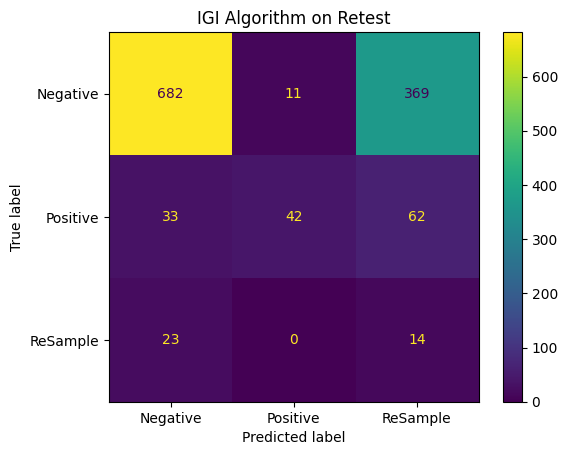

In [8]:
cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.igi_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('IGI Algorithm on Retest')

Text(0.5, 1.0, 'IGI Manual on Retest')

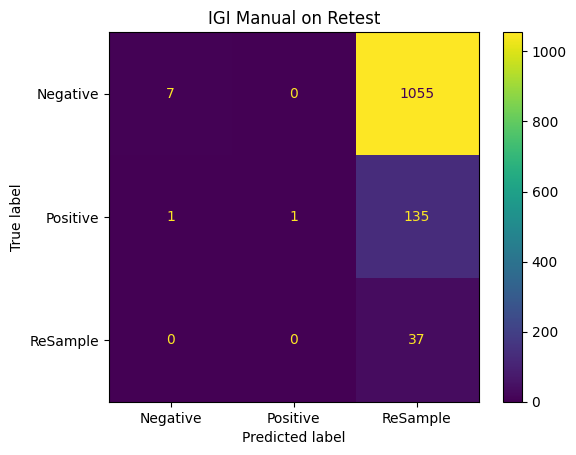

In [9]:

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.current_sample_result_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('IGI Manual on Retest')

c) This performance problems may be driven by the simple threshold-based classification rule implemented by the IGI, which neglects further information provided by the complete amplification trajectory
### Manually pick out curves

In [10]:
# pd.set_option('display.max_rows', None)
# (groundtruth_df
# #  .loc[groundtruth_df.encoded_igi_call != groundtruth_df.groundtruth_label,
#  .loc[(groundtruth_df.encoded_igi_call == 0) & (groundtruth_df.groundtruth_label == 1),
#       ['curve_idx','encoded_igi_call','groundtruth_label']].drop_duplicates()
#  .merge(join_df[['curve_idx','sample_type','target','well_position','amp_score','record_type','file']].drop_duplicates(), 
#         how='inner', on='curve_idx')
#  .merge(fusion_vit_test_pred[['curve_idx','outputs']], how='inner', on='curve_idx')
#  .sort_values(['outputs','amp_score']))

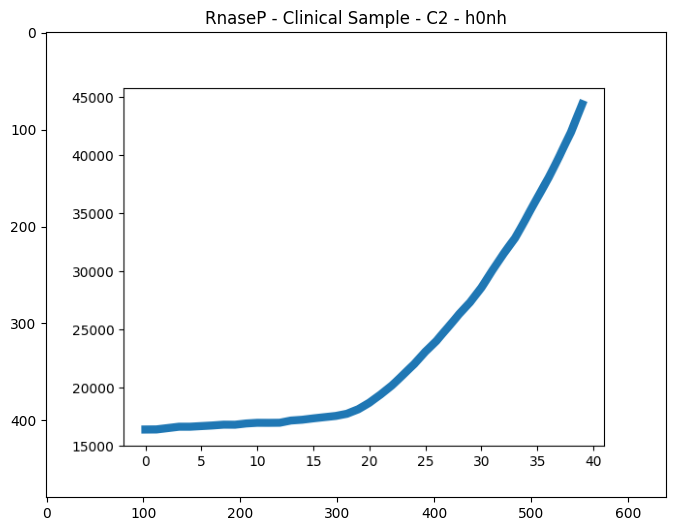

In [11]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

fig = plt.figure(frameon=False)
fig.set_size_inches(8,10)

img = mpimg.imread('../data/curve_imgs_axis/curve_81867.png')
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
# fig.add_axes(ax)
# ax.bar_label(ax.containers[0])
# plt.title('Contribution')

plt.title('RnaseP - Clinical Sample - C2 - h0nh')
plt.imshow(img)
plt.show()

### High level analysis on retest samples

In [45]:
dd = join_df.loc[(join_df.retest_sample_id_1 != ' ') & (join_df.cycle_no == 40)]

dd.groupby('current_sample_result').sample_id.nunique()

current_sample_result
Inconclusive    324
Invalid         903
Negative          8
Positive          1
Name: sample_id, dtype: int64

In [46]:
dd.loc[(dd.current_sample_result == 'Inconclusive') & 
       (dd.final_patient_result == 'Negative') & 
       (~dd.target.isin(['MS2','RnaseP'])) &
       (dd.igi_call == 'Positive')].groupby(['target']).curve_idx.nunique()

target
E gene     18
N gene    176
ORF1ab     25
S gene     37
Name: curve_idx, dtype: int64

## Threshold change analysis
### Test set

In [12]:

# test_df2 = (fusion_vit_test_pred
#  .merge(join_df[['curve_idx','igi_call','threshold', 'drn', 'cq', 'cycle_no', 'file', 'well_position','test_kit']].drop_duplicates(),
#         how = 'inner', on = 'curve_idx'))

# # test_df2['encoded_igi_call'] = 1*(test_df2['igi_call'] == 'Positive')

# test_thresholds = {'Thres accuracy': [],
#               'Thres FNR': [],
#               'Thres TNR': [],
#               'Thres FPR': [],
#               'Thres TPR': []}

# search_space = np.arange(16)*0.02
# search_space = np.concatenate([search_space, search_space[1:]*-1])

# for rate in search_space:
#     test_df3 = test_df2.copy()
#     test_df3['temp'] = np.nan
    
#     if rate == 0:
#         test_df3['new_igi_call'] = test_df3['encoded_igi_call']
#     else:
#         test_df3['new_igi_call'] = 0
    
#         for file in test_df2.file.unique():
#             df = test_df2[test_df2.file == file]
#             for target in test_df2.target.unique():
#                 threshold = df[df.target == target].threshold.mean()
                
#                 new_threshold = (1+rate) * threshold
#                 df.loc[(df.target == target) & (df.file == file), 'temp'] = 1*(df.loc[(df.target == target) & (df.file == file), 'drn'] >= new_threshold)
#                 min_cycle_df = df[df.temp == 1].groupby(['curve_idx','test_kit']).cycle_no.min().reset_index()
                
#                 min_cycle_df['new_igi_call'] = 0
                
#                 if min_cycle_df.test_kit.unique() == 'Thermo':
#                     min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 37)
#                 else:
#                     if target == 'RnaseP':
#                         min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 35)
#                     else:
#                         min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 40)

#                 for idx in min_cycle_df.curve_idx.unique():
#                     test_df3.loc[test_df3.curve_idx == idx, 'new_igi_call'] = min_cycle_df[min_cycle_df.curve_idx == idx].new_igi_call.mean()

#     result_df = test_df3[['curve_idx','groundtruth_label','encoded_igi_call','new_igi_call']].drop_duplicates()

#     tn, fp, fn, tp  = confusion_matrix(result_df.groundtruth_label, result_df.new_igi_call).ravel()

#     test_thresholds['Thres accuracy'].append((tp + tn)/(tp+tn+fp+fn))
#     test_thresholds['Thres FNR'].append(fn/(fn+tp))
#     test_thresholds['Thres TNR'].append(tn/(tn+fp))
#     test_thresholds['Thres FPR'].append(fp/(fp+tn))
#     test_thresholds['Thres TPR'].append(tp/(tp+fn))

# test_thresholds_df = pd.DataFrame(test_thresholds)
# test_thresholds_df.to_csv('../data/test_thresholds.csv', index=False)
test_thresholds_df = pd.read_csv('../data/test_thresholds.csv')


### Retest set

In [13]:
# retest_df2 = (fusion_vit_retest_pred
#  .merge(join_df[['sample_id','curve_idx','target','igi_call','final_patient_result','current_sample_result', 'threshold', 'drn', 'cq', 'cycle_no', 'file']].drop_duplicates(),
#         how = 'inner', on = 'curve_idx'))
# retest_df2['test_kit'] = retest_df2.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
# retest_df2['test_kit'] = np.where(retest_df2.test_kit == 3, 'Thermo', 'LuNER')
# retest_df2['groundtruth_label'] = 0.
# retest_df2.loc[retest_df2.target.isin(['RnaseP','MS2']), 'groundtruth_label'] = 1.0
# retest_df2.loc[(~retest_df2.target.isin(['RnaseP','MS2'])) & (retest_df2.final_patient_result == 'Positive'), 'groundtruth_label'] = 1.0
# retest_df2['encoded_igi_call'] = 1*(retest_df2['igi_call'] == 'Positive')

# retest_thresholds = {'Thres accuracy': [],
#               'Thres FNR': [],
#               'Thres TNR': [],
#               'Thres FPR': [],
#               'Thres TPR': []}

# search_space = np.linspace(-0.3, 0.3,30)
# for rate in search_space:
#     retest_df3 = retest_df2.copy()
#     retest_df3['temp'] = np.nan
    
#     if rate == 0:
#         retest_df3['new_igi_call'] = retest_df3['encoded_igi_call']
#     else:
#         retest_df3['new_igi_call'] = 0
    
#     for file in retest_df2.file.unique():
#         df = retest_df2[retest_df2.file == file]
#         for target in retest_df2.target.unique():
#             threshold = df[df.target == target].threshold.mean()
            
#             new_threshold = (1+rate) * threshold
#             df.loc[(df.target == target) & (df.file == file), 'temp'] = 1*(df.loc[(df.target == target) & (df.file == file), 'drn'] >= new_threshold)
#             min_cycle_df = df[df.temp == 1].groupby(['curve_idx','test_kit']).cycle_no.min().reset_index()
            
#             min_cycle_df['new_igi_call'] = 0
            
#             if min_cycle_df.test_kit.unique() == 'Thermo':
#                 min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 37)
#             else:
#                 if target == 'RnaseP':
#                     min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 35)
#                 else:
#                     min_cycle_df['new_igi_call'] = 1*(min_cycle_df.cycle_no < 40)

#             for idx in min_cycle_df.curve_idx.unique():
#                 retest_df3.loc[retest_df3.curve_idx == idx, 'new_igi_call'] = min_cycle_df[min_cycle_df.curve_idx == idx].new_igi_call.mean()

#     result_df = retest_df3[['curve_idx','groundtruth_label','new_igi_call']].drop_duplicates()

#     tn, fp, fn, tp = confusion_matrix(result_df.groundtruth_label, result_df.new_igi_call).ravel()

#     retest_thresholds['Thres accuracy'].append((tn+tp)/(tn+tp+fn+fp))
#     retest_thresholds['Thres FNR'].append(fn/(fn+tp))
#     retest_thresholds['Thres TNR'].append(tn/(tn+fp))
#     retest_thresholds['Thres FPR'].append(fp/(fp+tn))
#     retest_thresholds['Thres TPR'].append(tp/(tp+fn))

# retest_thresholds_df = pd.DataFrame(retest_thresholds)
# retest_thresholds_df.to_csv('../data/retest_thresholds.csv', index=False)

retest_thresholds_df = pd.read_csv('../data/retest_thresholds.csv')

### 2) We have developed a machine learning model that surpasses the accuracy of the IGI on a test set of control samples
#### a) AUC


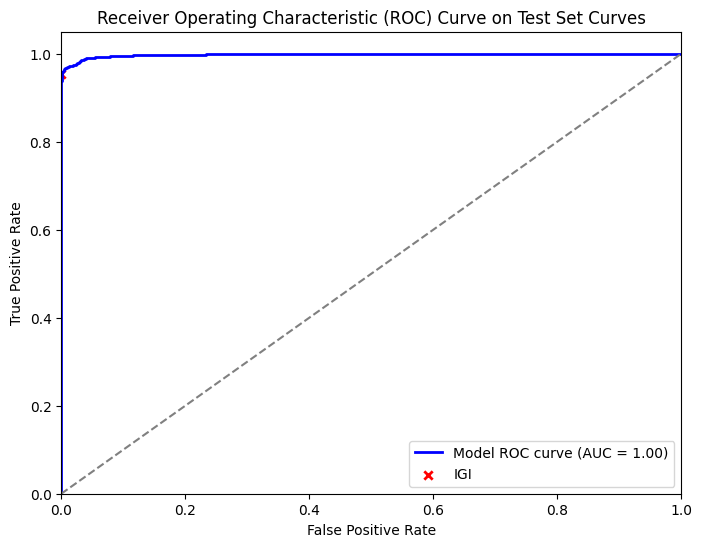

In [14]:

test_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(igi_fpr, igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set Curves')
plt.legend(loc='lower right')
plt.show()


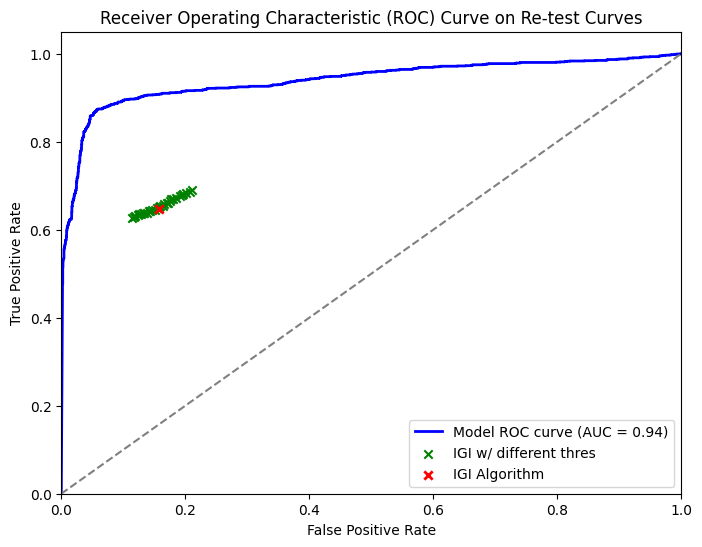

In [15]:
retest_auc = roc_auc_score(retest_df.groundtruth_label, retest_df.outputs)
retest_fpr, retest_tpr, retest_thresholds = roc_curve(retest_df.groundtruth_label, retest_df.outputs)

plt.figure(figsize=(8, 6))
plt.plot(retest_fpr, retest_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(retest_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))

for i in range(retest_thresholds_df.shape[0] - 1):
    plt.scatter(retest_thresholds_df.loc[i,'Thres FPR'], retest_thresholds_df.loc[i, 'Thres TPR'], color='green', marker='x')

plt.scatter(retest_thresholds_df.loc[29,'Thres FPR'], retest_thresholds_df.loc[29, 'Thres TPR'], color='green', marker='x', label='IGI w/ different thres')
plt.scatter(retest_igi_fpr, retest_igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI Algorithm')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Curves')
plt.legend(loc='lower right')
plt.show()


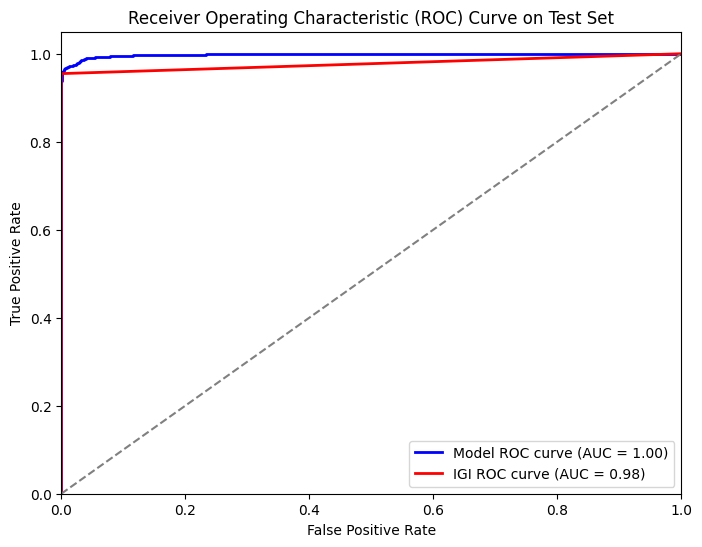

In [16]:
# test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
# test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

# test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
# test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


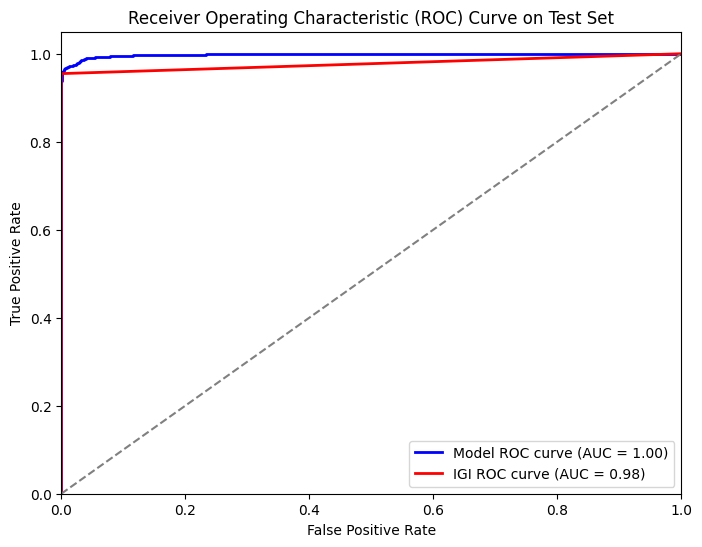

In [17]:
# test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
# test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

# test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
# test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


In [59]:
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
tnr, fnr, tpr, fpr, accuracy, pos_rate = [], [], [], [], [], []
for thres in thresholds:
    pred = 1*(fusion_vit_test_pred.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, pred).ravel()
    
    tnr.append(tn/(tn+fp))
    fnr.append(fn/(fn + tp))
    fpr.append(fp/(fp + tn))
    tpr.append(tp/(tp+fn))
    accuracy.append((tp+tn)/len(pred))    
    pos_rate.append((tp + fp)/(tn + fp + fn + tp))

best_acc_idx = np.array(accuracy).argmax()
best_acc_thres = thresholds[best_acc_idx]

<Axes: >

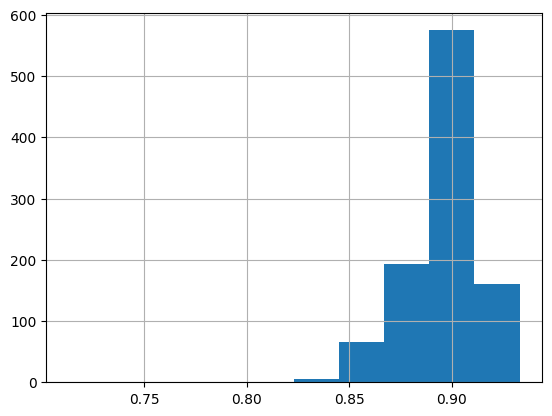

In [61]:
dd = pd.DataFrame({'pos_rate': pos_rate})
dd['neg_rate'] = 1 - dd.pos_rate
dd.pos_rate.hist()

<Axes: >

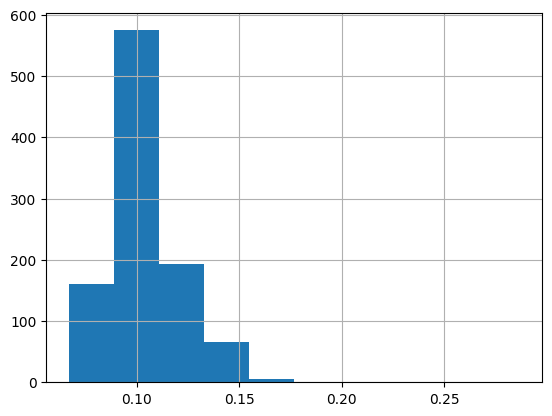

In [62]:
dd.neg_rate.hist()

In [64]:
fusion_vit_test_pred.groupby('groundtruth_label').curve_idx.count()

groundtruth_label
0     623
1    5552
Name: curve_idx, dtype: int64

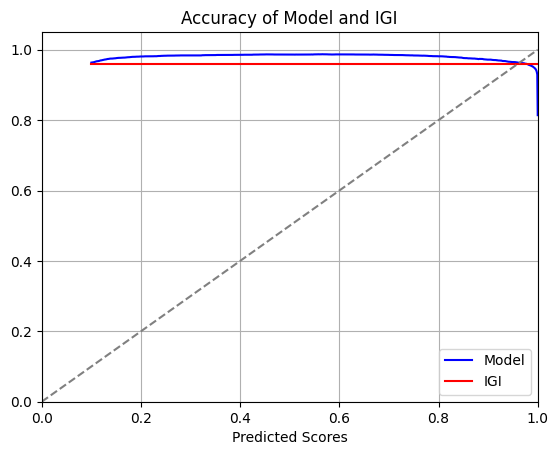

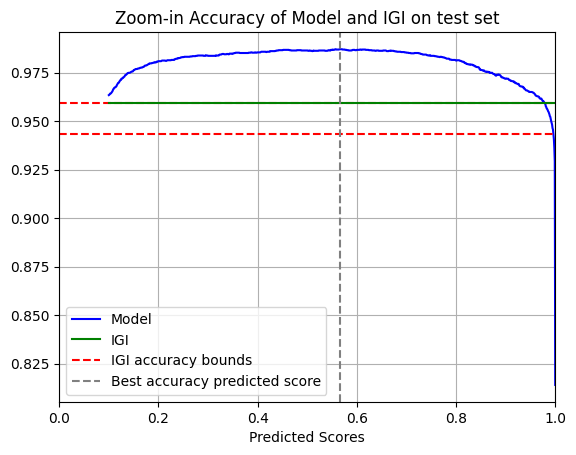

In [23]:
plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI')
plt.show()

plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres accuracy'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres accuracy'].min(), color = 'red', linestyle='--', label='IGI accuracy bounds')
plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Accuracy of Model and IGI on test set')
plt.show()


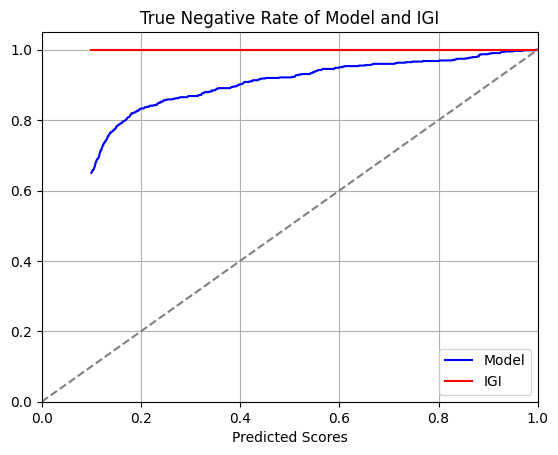

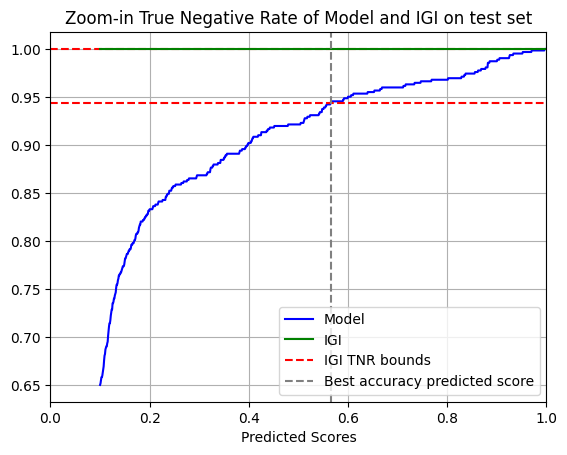

In [20]:
plt.plot(thresholds, tnr, color='blue', label='Model')
plt.plot(thresholds, [igi_tnr]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('True Negative Rate of Model and IGI')
plt.show()

plt.plot(thresholds, tnr, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres TNR'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [igi_tnr]*len(thresholds), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres TNR'].min(), color = 'red', linestyle='--', label='IGI TNR bounds')
plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.93, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in True Negative Rate of Model and IGI on test set')
plt.show()


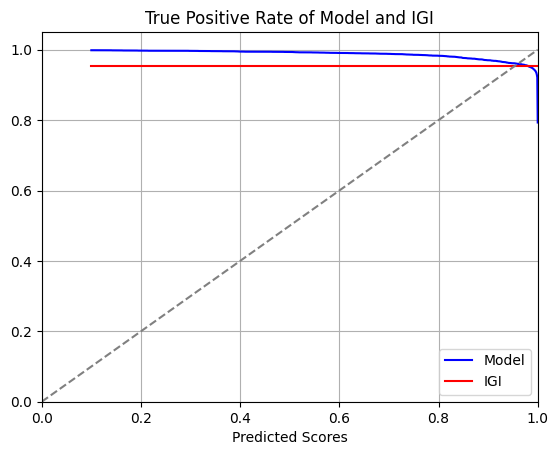

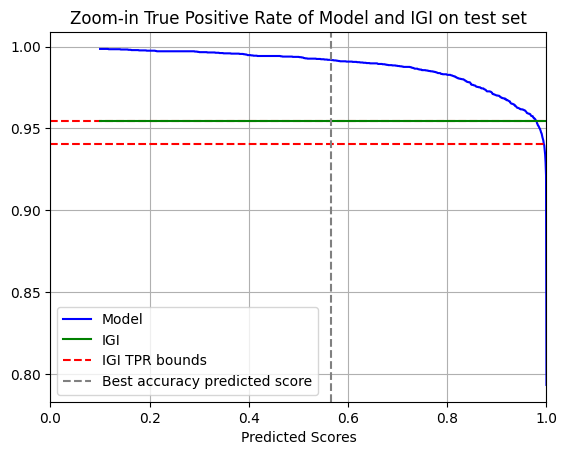

In [21]:
plt.plot(thresholds, tpr, color='blue', label='Model')
plt.plot(thresholds, [igi_tpr]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('True Positive Rate of Model and IGI')
plt.show()

plt.plot(thresholds, tpr, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres TPR'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [igi_tpr]*len(thresholds), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres TPR'].min(), color = 'red', linestyle='--', label='IGI TPR bounds')
plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in True Positive Rate of Model and IGI on test set')
plt.show()


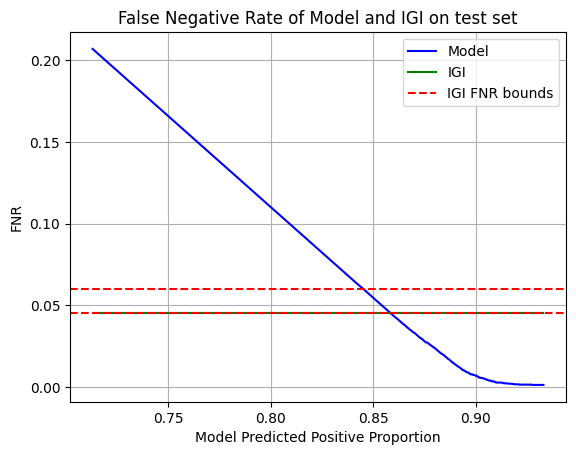

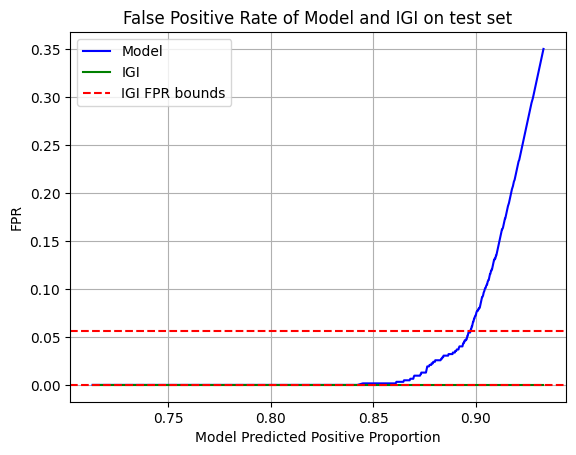

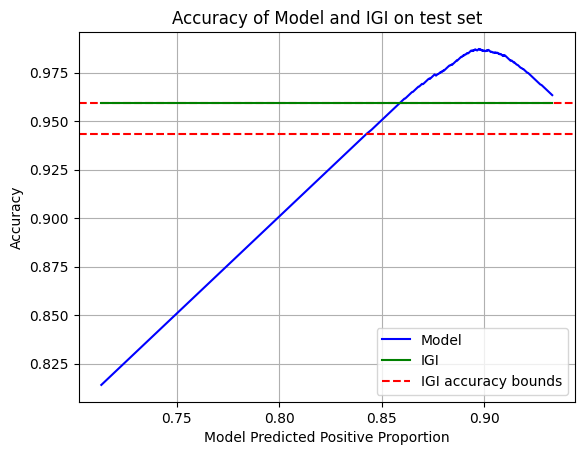

In [39]:
# plt.plot(thresholds, accuracy, color='blue', label='Model')
# plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
# plt.xlabel('Predicted Scores')
# plt.xlim([0,1])
# plt.ylim([0,1.05])
# plt.legend()
# plt.grid()
# plt.title('Accuracy of Model and IGI')
# plt.show()

plt.plot(pos_rate, fnr, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres FNR'].max(), color = 'red', linestyle='--')
plt.plot(pos_rate, [igi_fnr]*len(pos_rate), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres FNR'].min(), color = 'red', linestyle='--', label='IGI FNR bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('FNR')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('False Negative Rate of Model and IGI on test set')
plt.show()

plt.plot(pos_rate, fpr, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres FPR'].max(), color = 'red', linestyle='--')
plt.plot(pos_rate, [igi_fpr]*len(pos_rate), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres FPR'].min(), color = 'red', linestyle='--', label='IGI FPR bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('FPR')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('False Positive Rate of Model and IGI on test set')
plt.show()

plt.plot(pos_rate, accuracy, color='blue', label='Model')
plt.axhline(test_thresholds_df['Thres accuracy'].max(), color = 'red', linestyle='--')
plt.plot(pos_rate, [igi_acc]*len(pos_rate), color='green', label='IGI')
plt.axhline(test_thresholds_df['Thres accuracy'].min(), color = 'red', linestyle='--', label='IGI accuracy bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('Accuracy')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI on test set')
plt.show()


In [35]:
igi_fnr, igi_fpr, igi_acc

(0.04520893371757925, 0.0, 0.9593522267206478)

In [37]:
fnr[best_acc_idx], fpr[best_acc_idx], accuracy[best_acc_idx]

(0.008105187319884726, 0.05457463884430177, 0.9872064777327936)

### Retest

In [55]:
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
retest_tnr, retest_fnr, retest_tpr, retest_fpr, retest_accuracy, retest_pos_rate = [], [], [], [], [], []
for thres in thresholds:
    pred = 1*(retest_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(retest_df.groundtruth_label, pred).ravel()
    
    retest_tnr.append(tn/(tn+fp))
    retest_fnr.append(fn/(fn+tp))
    retest_tpr.append(tp/(tp+fn))
    retest_fpr.append(fp/(fp+tn))
    retest_accuracy.append((tp+tn)/len(pred))
    retest_pos_rate.append((tp+fp)/(tp+fp+tn+fn))


retest_best_acc_idx = np.array(retest_accuracy).argmax()
retest_best_acc_thres = thresholds[retest_best_acc_idx]

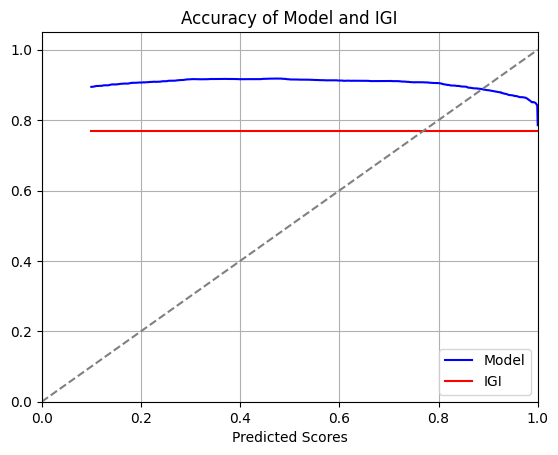

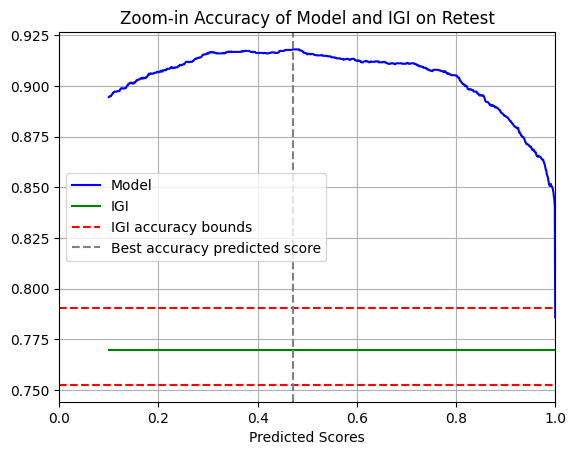

In [52]:
plt.plot(thresholds, retest_accuracy, color='blue', label='Model')
plt.plot(thresholds, [retest_igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI')
plt.show()

plt.plot(thresholds, retest_accuracy, color='blue', label='Model')
plt.axhline(retest_thresholds_df['Thres accuracy'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [retest_igi_acc]*len(thresholds), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres accuracy'].min(), color = 'red', linestyle='--',label='IGI accuracy bounds')
plt.axvline(x=retest_best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Accuracy of Model and IGI on Retest')
plt.show()


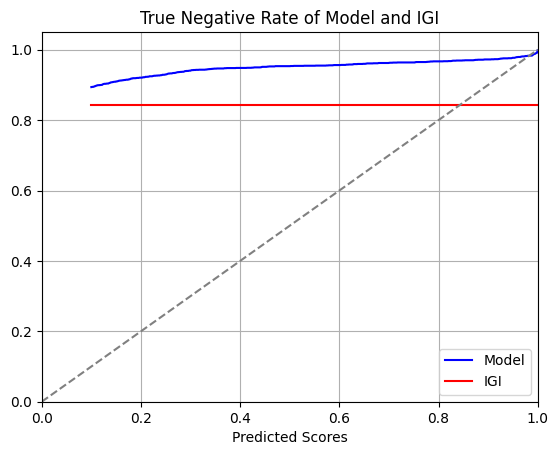

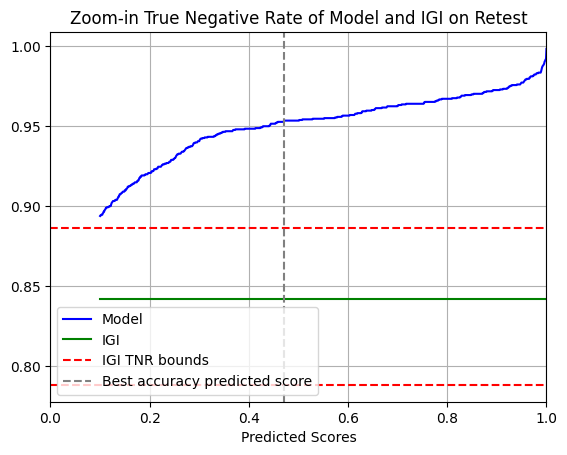

In [53]:
plt.plot(thresholds, retest_tnr, color='blue', label='Model')
plt.plot(thresholds, [retest_igi_tnr]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('True Negative Rate of Model and IGI')
plt.show()

plt.plot(thresholds, retest_tnr, color='blue', label='Model')

plt.axhline(retest_thresholds_df['Thres TNR'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [retest_igi_tnr]*len(thresholds), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres TNR'].min(), color = 'red', linestyle='--', label='IGI TNR bounds')
plt.axvline(x=retest_best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.93, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in True Negative Rate of Model and IGI on Retest')
plt.show()


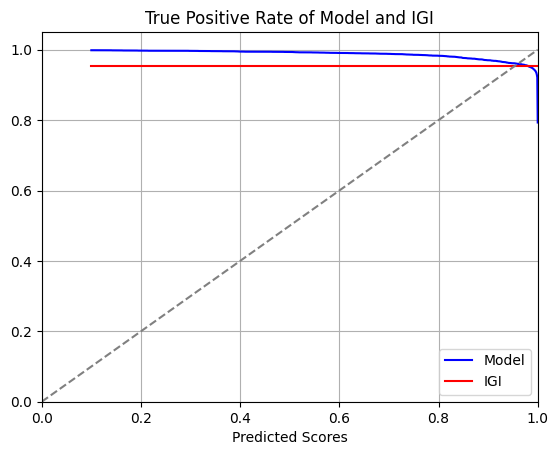

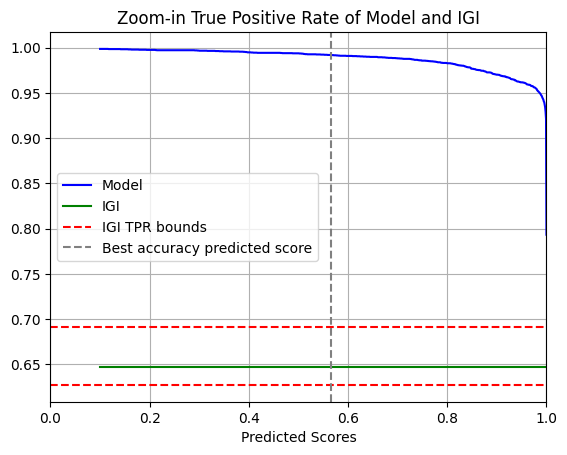

In [54]:
plt.plot(thresholds, tpr, color='blue', label='Model')
plt.plot(thresholds, [igi_tpr]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('True Positive Rate of Model and IGI')
plt.show()

plt.plot(thresholds, tpr, color='blue', label='Model')

plt.axhline(retest_thresholds_df['Thres TPR'].max(), color = 'red', linestyle='--')
plt.plot(thresholds, [retest_igi_tpr]*len(thresholds), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres TPR'].min(), color = 'red', linestyle='--', label='IGI TPR bounds')

plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
# plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in True Positive Rate of Model and IGI')
plt.show()


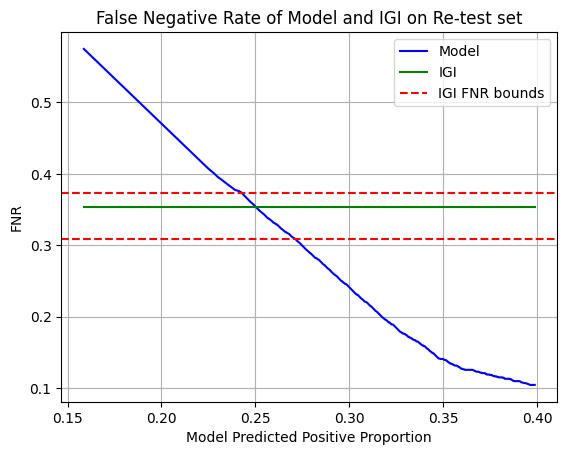

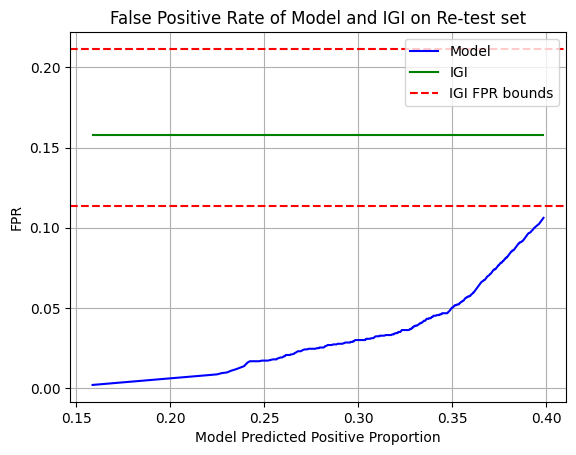

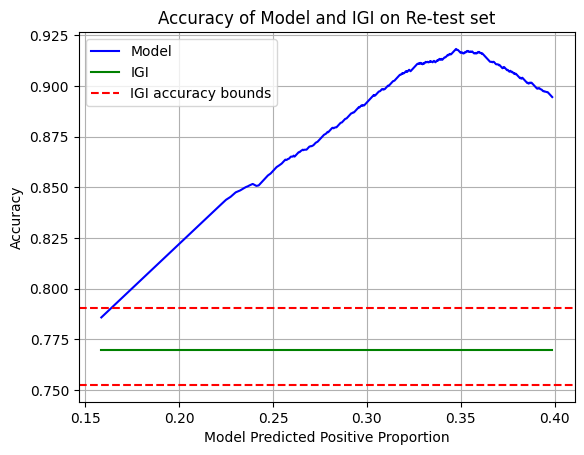

In [56]:
# plt.plot(thresholds, accuracy, color='blue', label='Model')
# plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
# plt.xlabel('Predicted Scores')
# plt.xlim([0,1])
# plt.ylim([0,1.05])
# plt.legend()
# plt.grid()
# plt.title('Accuracy of Model and IGI')
# plt.show()

plt.plot(retest_pos_rate, retest_fnr, color='blue', label='Model')
plt.axhline(retest_thresholds_df['Thres FNR'].max(), color = 'red', linestyle='--')
plt.plot(retest_pos_rate, [retest_igi_fnr]*len(retest_pos_rate), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres FNR'].min(), color = 'red', linestyle='--', label='IGI FNR bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('FNR')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('False Negative Rate of Model and IGI on Re-test set')
plt.show()

plt.plot(retest_pos_rate, retest_fpr, color='blue', label='Model')
plt.axhline(retest_thresholds_df['Thres FPR'].max(), color = 'red', linestyle='--')
plt.plot(retest_pos_rate, [retest_igi_fpr]*len(retest_pos_rate), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres FPR'].min(), color = 'red', linestyle='--', label='IGI FPR bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('FPR')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('False Positive Rate of Model and IGI on Re-test set')
plt.show()

plt.plot(retest_pos_rate, retest_accuracy, color='blue', label='Model')
plt.axhline(retest_thresholds_df['Thres accuracy'].max(), color = 'red', linestyle='--')
plt.plot(retest_pos_rate, [retest_igi_acc]*len(retest_pos_rate), color='green', label='IGI')
plt.axhline(retest_thresholds_df['Thres accuracy'].min(), color = 'red', linestyle='--', label='IGI accuracy bounds')
# plt.axvline(x=best_acc_thres, color='gray', linestyle='--', label='Best accuracy predicted score')
# plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Model Predicted Positive Proportion')
plt.ylabel('Accuracy')
# plt.xlim([0,1])
# plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI on Re-test set')
plt.show()


a) Picking threshold based on criteria

In [51]:
## test set
thresholds = np.linspace(0.1, 1, 1000)
tns, tps, fns, fps = [], [], [], []
for thres in thresholds:
    pred = 1*(fusion_vit_test_pred.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, pred).ravel()
    tns.append(tn)
    tps.append(tp)
    fns.append(fn)
    fps.append(fp)

tns, tps, fns, fps = np.array(tns), np.array(tps), np.array(fns), np.array(fps)

accuracy = (tps+tns)/(tps+tns+fps+fns)
precision = (tps)/(tps + fps)
sensitivity = (tps)/(tps + fns)
neg_preds = fns + tns
f1_scores = 2*tps/(2*tps + fps + fns)
fpr = fps/(fps + tns)
fnr = fns/(fns + tps)

## retest set
retest_tns, retest_tps, retest_fns, retest_fps = [], [], [], []
for thres in thresholds:
    pred = 1*(retest_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(retest_df.groundtruth_label, pred).ravel()
    retest_tns.append(tn)
    retest_tps.append(tp)
    retest_fns.append(fn)
    retest_fps.append(fp)

retest_tns, retest_tps, retest_fns, retest_fps = np.array(retest_tns), np.array(retest_tps), np.array(retest_fns), np.array(retest_fps)

retest_accuracy = (retest_tps+retest_tns)/(retest_tps+retest_tns+retest_fps+retest_fns)
retest_precision = (retest_tps)/(retest_tps + retest_fps)
retest_sensitivity = (retest_tps)/(retest_tps + retest_fns)
retest_neg_preds = retest_fns + retest_tns
retest_f1_scores = 2*retest_tps/(2*retest_tps + retest_fps + retest_fns)
retest_fpr = retest_fps/(retest_fps + retest_tns)
retest_fnr = retest_fns/(retest_fns + retest_tps)




* Best accuracy

In [52]:
idx = accuracy.argmax()
best_acc_threshold = thresholds[idx]
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')

print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With TP = 5507; TN = 589; FP = 34; FN = 45
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With FNR = 0.008105187319884726 and FPR = 0.05457463884430177


In [53]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9135651322233105
With precision: 0.9166666666666666
With sensitivity: 0.8433575677461996
With F1 score: 0.8784853700516351
With TP = 1276; TN = 2455; FP = 116; FN = 237
With FNR = 0.1566424322538004 and FPR = 0.045118630882924934


Text(0.5, 1.0, 'Best Accuracy Threshold on Retest')

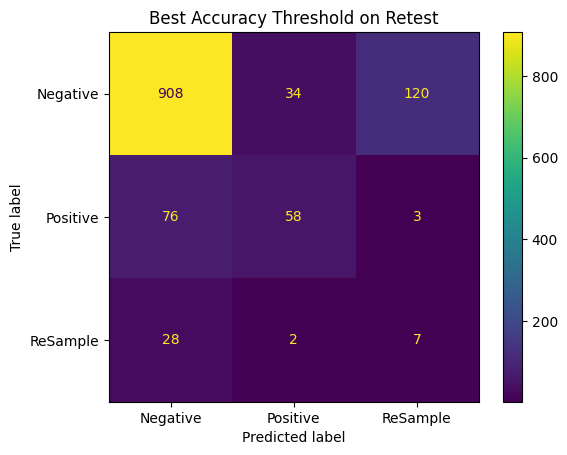

In [54]:
retest_sample = retest_df.copy()
retest_sample['pred'] = 1*(retest_sample.outputs >= thresholds[idx])
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.pred == 0)].sample_id

# model prediction
retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'),
      igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())

retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy Threshold on Retest')

* Best sensitivity

Since there is multplie thresholds that give the same maximum sensitivity, we pick the threshold that also has maximum precision and accuracy, lowest false negative rate and false positive rate among the group. 

In [55]:
ids = np.where(sensitivity == sensitivity.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [56]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.1
With accuracy: 0.9634008097165991
With precision: 0.9621659146129816
With sensitivity: 0.9985590778097982
With F1 score: 0.9800247480996995
With TP = 5544; TN = 405; FP = 218; FN = 8
With FNR = 0.001440922190201729 and FPR = 0.34991974317817015


In [57]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8944662095984329
With precision: 0.8323095823095823
With sensitivity: 0.8955717118307998
With F1 score: 0.862782553326966
With TP = 1355; TN = 2298; FP = 273; FN = 158
With FNR = 0.10442828816920026 and FPR = 0.10618436406067679


Text(0.5, 1.0, 'Best Sensitivity Threshold on Retest')

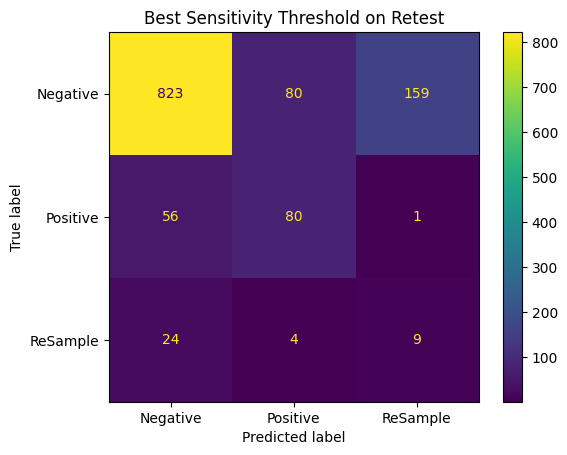

In [58]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity Threshold on Retest')

* Best precision

Since there is multplie thresholds that give the same maximum precision, we pick the threshold that also has maximum sensitivity and accuracy, lowest false negative rate and false positive rate among the group. 

In [59]:
ids = np.where(precision == precision.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_scores': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [60]:
idx = df.sort_values('sensitivity', ascending=False).reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.06304034582132564 and FPR = 0.0


In [61]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8474534769833496
With precision: 0.973404255319149
With sensitivity: 0.6047587574355585
With F1 score: 0.7460252751732572
With TP = 915; TN = 2546; FP = 25; FN = 598
With FNR = 0.3952412425644415 and FPR = 0.009723842862699339


Text(0.5, 1.0, 'Best Precision Threshold on Retest')

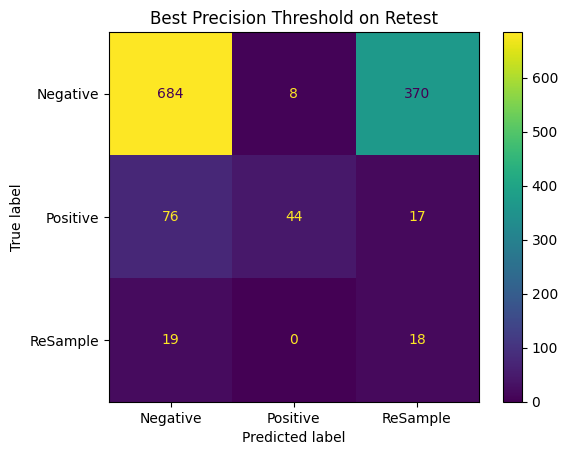

In [62]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision Threshold on Retest')

* Best f1 score

In [63]:
idx = f1_scores.argmax()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With TP = 5507; TN = 589; FP = 34; FN = 45
With FNR = 0.008105187319884726 and FPR = 0.05457463884430177


In [64]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9135651322233105
With precision: 0.9166666666666666
With sensitivity: 0.8433575677461996
With F1 score: 0.8784853700516351
With TP = 1276; TN = 2455; FP = 116; FN = 237
With FNR = 0.1566424322538004 and FPR = 0.045118630882924934


Text(0.5, 1.0, 'Best Accuracy / F1 Score Threshold on Retest')

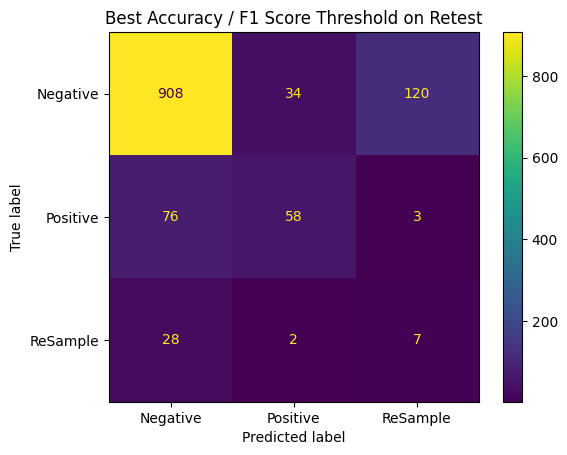

In [65]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy / F1 Score Threshold on Retest')

* Best false negative rate

In [66]:
idx = fnr.argmin()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.1
With accuracy: 0.9634008097165991
With precision: 0.9621659146129816
With sensitivity: 0.9985590778097982
With F1 score: 0.9800247480996995
With TP = 5544; TN = 405; FP = 218; FN = 8
With FNR = 0.001440922190201729 and FPR = 0.34991974317817015


In [67]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8944662095984329
With precision: 0.8323095823095823
With sensitivity: 0.8955717118307998
With F1 score: 0.862782553326966
With TP = 1355; TN = 2298; FP = 273; FN = 158
With FNR = 0.10442828816920026 and FPR = 0.10618436406067679


Text(0.5, 1.0, 'Best Sensitivity / False Negative Rate Threshold on Retest')

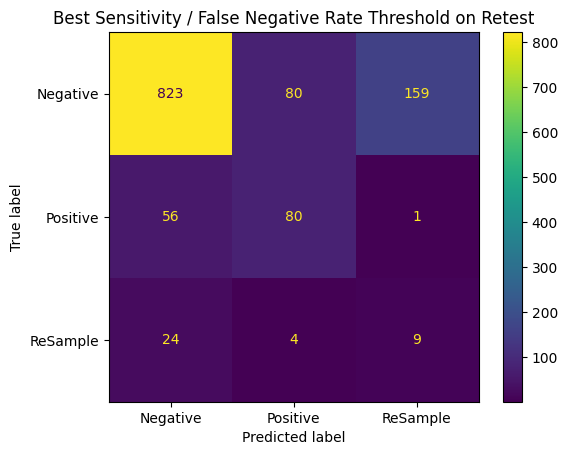

In [68]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity / False Negative Rate Threshold on Retest')

* Best false positive rate

In [69]:
ids = np.where(fpr == fpr.min())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [70]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.06304034582132564 and FPR = 0.0


In [71]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8474534769833496
With precision: 0.973404255319149
With sensitivity: 0.6047587574355585
With F1 score: 0.7460252751732572
With TP = 915; TN = 2546; FP = 25; FN = 598
With FNR = 0.3952412425644415 and FPR = 0.009723842862699339


Text(0.5, 1.0, 'Best Precision / False Positive Rate Threshold on Retest')

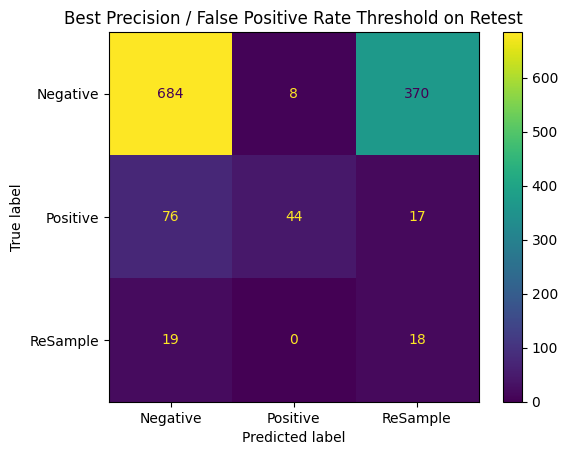

In [72]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision / False Positive Rate Threshold on Retest')

b) Picking threshold based on matching metrics with igi_acc
* False Positive Rate

In [73]:
ids = np.where(fpr == igi_fpr)

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])

In [74]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'IGI fpr: {igi_fpr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fpr: 0.0
Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.06304034582132564 and FPR = 0.0


In [75]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8474534769833496
With precision: 0.973404255319149
With sensitivity: 0.6047587574355585
With F1 score: 0.7460252751732572
With TP = 915; TN = 2546; FP = 25; FN = 598
With FNR = 0.3952412425644415 and FPR = 0.009723842862699339


Text(0.5, 1.0, 'Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

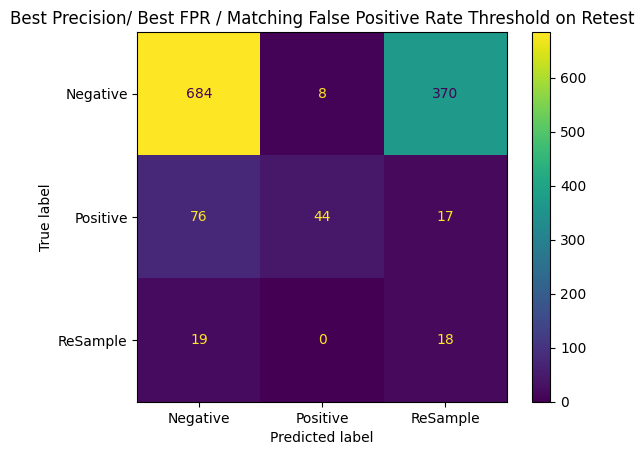

In [76]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

* False negative rate

In [77]:
idx = np.where(np.round(fnr,3) == round(igi_fnr,3))[0][0]
print(f'IGI fnr: {igi_fnr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fnr: 0.04520893371757925
Model AUC: 0.997836882057165
We use threshold at: 0.9783783783783784
With accuracy: 0.9593522267206478
With precision: 0.9998114274938714
With sensitivity: 0.954971181556196
With F1 score: 0.9768770152003685
With TP = 5302; TN = 622; FP = 1; FN = 250
With FNR = 0.04502881844380403 and FPR = 0.0016051364365971107


In [78]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8616552399608227
With precision: 0.9557692307692308
With sensitivity: 0.6569729015201586
With F1 score: 0.7786917352134743
With TP = 994; TN = 2525; FP = 46; FN = 519
With FNR = 0.34302709847984136 and FPR = 0.017891870867366783


Text(0.5, 1.0, 'Matching False Negative Rate Threshold on Retest')

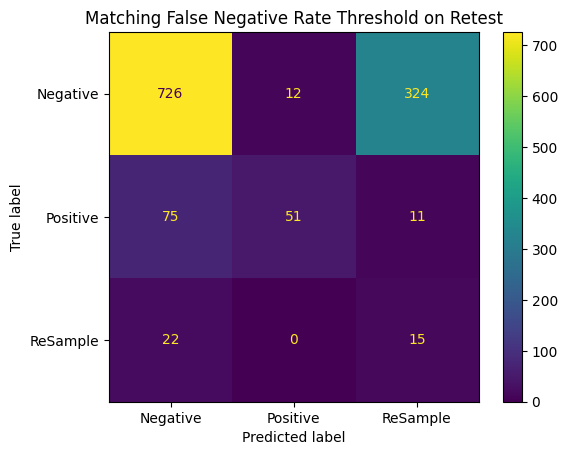

In [79]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching False Negative Rate Threshold on Retest')

* Positive predictions

In [80]:
idx = np.where((tps + fps) == (igi_tp + igi_fp))[0][0]
print(f'IGI number of positive prediction: {igi_tp + igi_fp}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of positive prediction: 5301
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.045389048991354465 and FPR = 0.0016051364365971107


In [81]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8606758080313418
With precision: 0.9564796905222437
With sensitivity: 0.6536682088565764
With F1 score: 0.7765999214762466
With TP = 989; TN = 2526; FP = 45; FN = 524
With FNR = 0.34633179114342366 and FPR = 0.01750291715285881


Text(0.5, 1.0, 'Matching Positive Prediction Threshold on Retest')

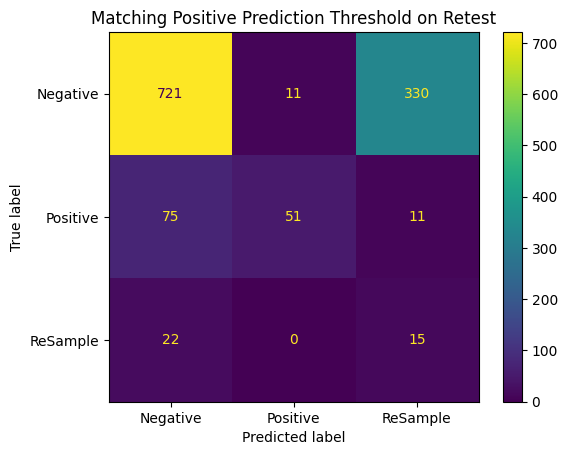

In [82]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive Prediction Threshold on Retest')

* Negative Predictions

In [83]:
idx = np.where((fns + tns) == (igi_fn + igi_tn))[0][0]
print(f'IGI number of negative prediction: {igi_tn + igi_fn}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of negative prediction: 874
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.045389048991354465 and FPR = 0.0016051364365971107


Text(0.5, 1.0, 'Matching Positive / Negative Prediction Threshold on Retest')

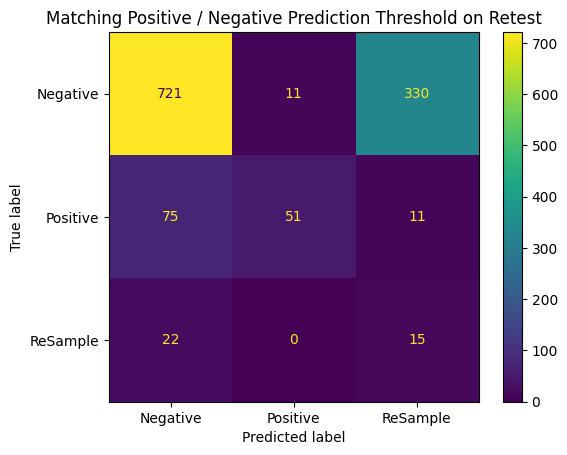

In [84]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive / Negative Prediction Threshold on Retest')

### Extra Plots

[]

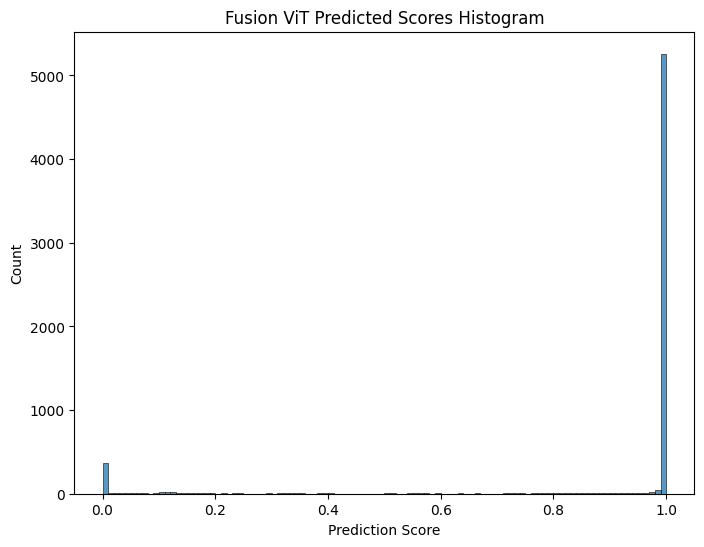

In [83]:
plt.figure(figsize=(8, 6))
sns.histplot(fusion_vit_test_pred, x = 'outputs', binwidth=0.01)
plt.title('Fusion ViT Predicted Scores Histogram')
plt.xlabel('Prediction Score')
plt.plot()

Text(0.5, 0, 'False Positive Rate')

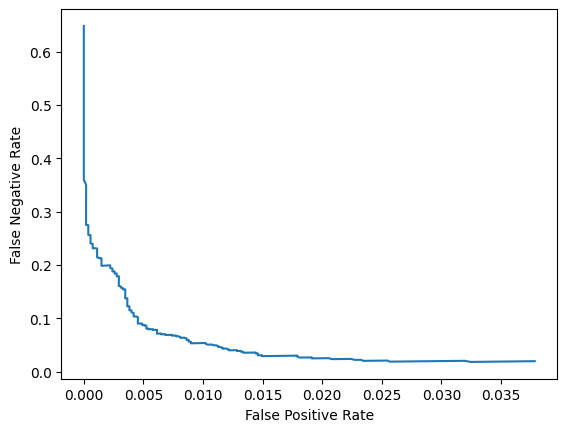

In [84]:
plt.plot(fpr, fnr)
plt.ylabel('False Negative Rate')
plt.xlabel('False Positive Rate')

[]

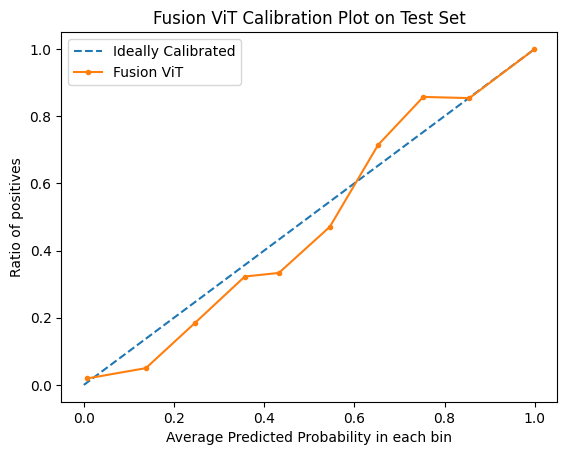

In [85]:
x,y = calibration_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot on Test Set')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

[]

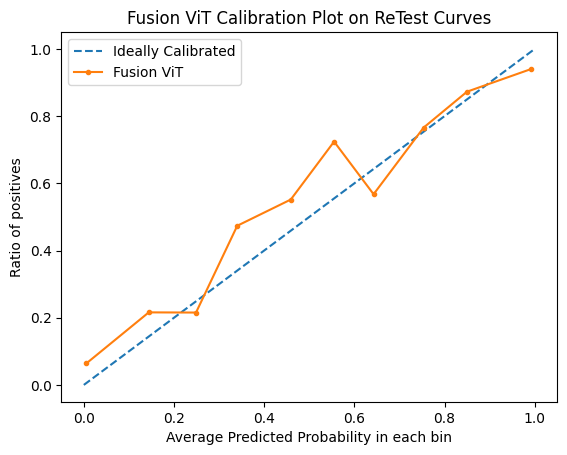

In [86]:
calibration_df = (retest_df
.merge(fusion_vit_retest_pred[['outputs','curve_idx']]))

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot on ReTest Curves')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

#### Deep Dive Analysis in Best Accuracy Model

In [85]:
retest_sample = retest_df.copy()
retest_sample['pred'] = 1*(retest_sample.outputs >= best_acc_threshold)
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.pred == 0)].sample_id
invalid_igi_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.encoded_igi_call == 0)]

# model prediction
retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'),
      igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())

retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

retest_sample_df['igi_pred'] = None
retest_sample_df.loc[retest_sample_df.igi_prob >= 0.5, 'igi_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.igi_prob > 0) & (retest_sample_df.igi_prob < 0.5), 'igi_pred'] = 'Inconclusive'
retest_sample_df['igi_pred_3'] = retest_sample_df.igi_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

best_acc_retest_df = (retest_sample
 .merge(retest_sample_df[['sample_id','sample_pred','igi_pred','sample_pred_3','igi_pred_3']], how='inner', on = 'sample_id'))

In [86]:
best_acc_retest_df.groupby('sample_pred').sample_id.nunique()

sample_pred
Inconclusive      75
Invalid           55
Negative        1012
Positive          94
Name: sample_id, dtype: int64

In [87]:
best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Inconclusive') &
                       (~best_acc_retest_df.target.isin(['MS2','RnaseP'])) &
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.pred == 1)].groupby('target').curve_idx.nunique()

target
N gene     4
ORF1ab    34
S gene    34
Name: curve_idx, dtype: int64

In [88]:
fn_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Negative') & 
                       (best_acc_retest_df.final_patient_result == 'Positive')].sample_id.nunique()
agree_fn_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Negative') & 
                       (best_acc_retest_df.final_patient_result == 'Positive') &
                       (best_acc_retest_df.sample_pred == best_acc_retest_df.igi_pred)
                       ].sample_id.nunique()
print(f'Number of False Negative: {fn_retest}')
print(f'Number of argreed False Negative between our model and IGI: {agree_fn_retest}')

Number of False Negative: 76
Number of argreed False Negative between our model and IGI: 31


In [89]:
fp_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Positive') & 
                       (best_acc_retest_df.final_patient_result == 'Negative')].sample_id.nunique()
agree_fp_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Positive') & 
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.sample_pred == best_acc_retest_df.igi_pred)
                       ].sample_id.nunique()
print(f'Number of False Positive: {fp_retest}')
print(f'Number of argreed False Positive between our model and IGI: {agree_fp_retest}')

Number of False Positive: 34
Number of argreed False Positive between our model and IGI: 32


In [90]:
negative_resample_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred_3 == 'ReSample') & 
                       (best_acc_retest_df.final_patient_result == 'Negative')].sample_id.nunique()
miss_negative_resample_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred_3 == 'ReSample') & 
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.final_patient_result == best_acc_retest_df.igi_pred_3)
                       ].sample_id.nunique()
print(f'Number of samples our model predicts to be resampled and groundtruth is Negative: {negative_resample_retest}')
print(f'Number of samples our model predicts to be resampled but IGI algorithm predicts correctly to be negative: {miss_negative_resample_retest}')

Number of samples our model predicts to be resampled and groundtruth is Negative: 120
Number of samples our model predicts to be resampled but IGI algorithm predicts correctly to be negative: 51


[]

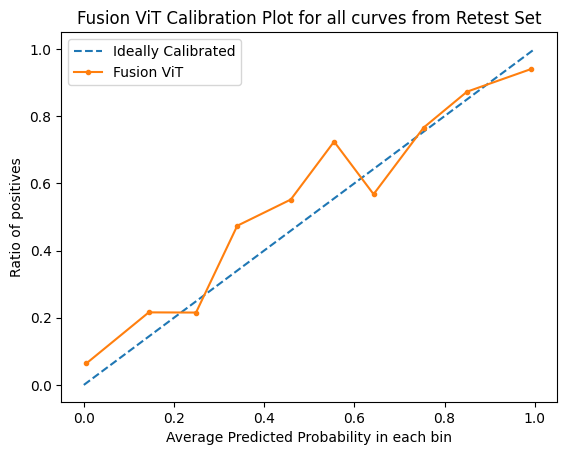

In [91]:
calibration_df = (retest_df
.merge(fusion_vit_retest_pred[['outputs','curve_idx']]))

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot for all curves from Retest Set')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

[]

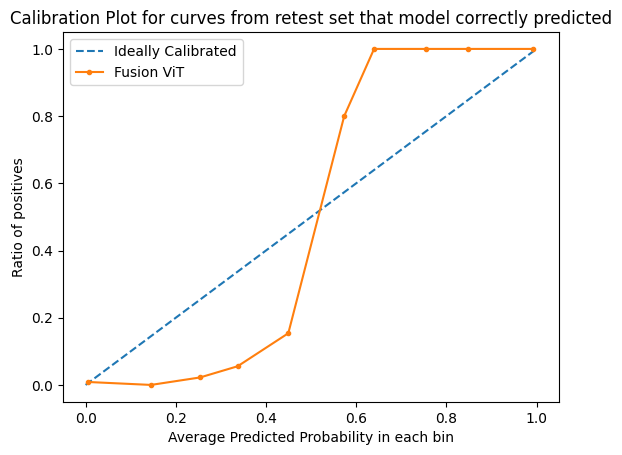

In [92]:
# best_acc_retest_df.head()
calibration_df = (best_acc_retest_df
                  .loc[(best_acc_retest_df.sample_pred_3 != 'ReSample') &
                       (best_acc_retest_df.final_patient_result == best_acc_retest_df.sample_pred_3)])

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Calibration Plot for curves from retest set that model correctly predicted')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

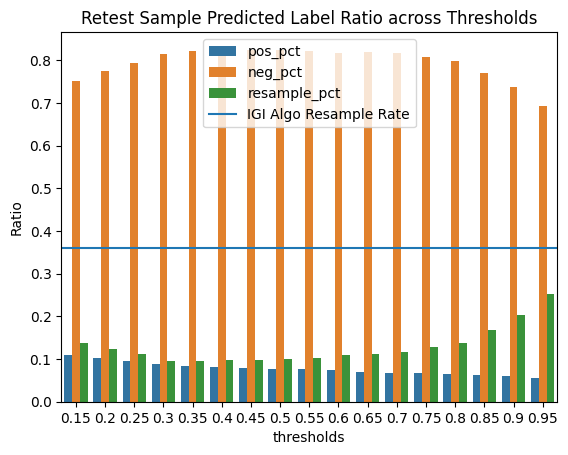

In [93]:
thresholds, pos_preds, neg_preds, resample_preds = [],[],[],[]

for i in range(15,100,5):
    retest_sample_df = retest_df.copy()
    retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= i/100)

    invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

    retest_sample_df = (retest_sample_df
                        .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
    .groupby(['sample_id','current_sample_result','final_patient_result'])
    .agg(sample_prob = ('pred', 'mean'))
    .reset_index())
    
    n_samples = retest_sample_df.shape[0]

    thresholds.append(i/100)
    pos_preds.append(retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5].shape[0]/n_samples)
    neg_preds.append(retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id))].shape[0]/n_samples)
    resample_preds.append((retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id))].shape[0] +
                            retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5)].shape[0])/n_samples)


threshold_retest_sample_df = pd.DataFrame({'thresholds': thresholds,
                                           'pos_pct': pos_preds,
                                           'neg_pct': neg_preds,
                                           'resample_pct': resample_preds})

hist_df = threshold_retest_sample_df.melt(id_vars=['thresholds'], var_name = 'Label', value_name = 'Ratio')

sns.barplot(data=hist_df, x='thresholds', y='Ratio', hue='Label', dodge=True)
plt.axhline(y=igi_algo_retest_sample_rate, label='IGI Algo Resample Rate')
plt.title('Retest Sample Predicted Label Ratio across Thresholds')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


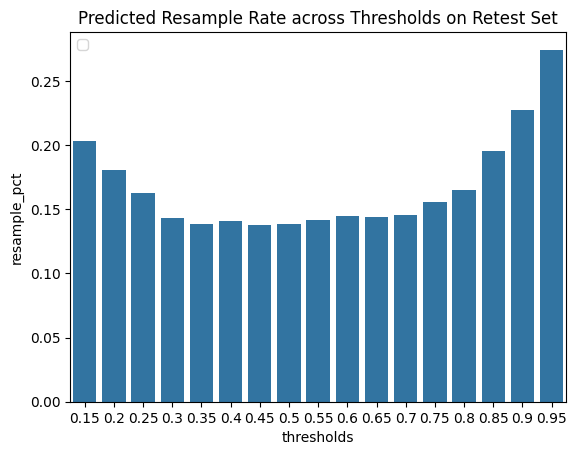

In [96]:
sns.barplot(data=threshold_retest_sample_df, x='thresholds', y='resample_pct')
plt.title('Predicted Resample Rate across Thresholds on Retest Set')
plt.legend()

### Methods to get thresholds
#### a) All sets
##### a.1) Same Threshold

Thresholds: {'RnaseP': 0.5441441441441441, 'MS2': 0.5441441441441441, 'S gene': 0.5441441441441441, 'E gene': 0.5441441441441441, 'ORF1ab': 0.5441441441441441, 'N gene': 0.5441441441441441}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9878423135956055
Model precision: 0.9941781749255348
Model sensitivity: 0.9922526012341787
Model F1 score: 0.9932144547893325
Model TP = 22029; TN = 2428; FP = 129; FN = 172
Model FNR = 0.06615384615384616 and FPR = 0.005821825074465204
-------------
On retest curves
-------------
Model accuracy: 0.9145445641527914
Model precision: 0.9163090128755365
Model sensitivity: 0.8466622604097819
Model F1 score: 0.880109927859842
Model TP = 1281; TN = 2454; FP = 117; FN = 232
Model FNR = 0.08637379002233805 and FPR = 0.08369098712446352
-------------
On Retest sample level
-------------
Model accuracy: 0.7888349514563107
Model FPR: 0.3829787234042553
Model FNR: 0.10334645669291342
Resamp

Text(0.5, 1.0, 'Same Threshold from All sets')

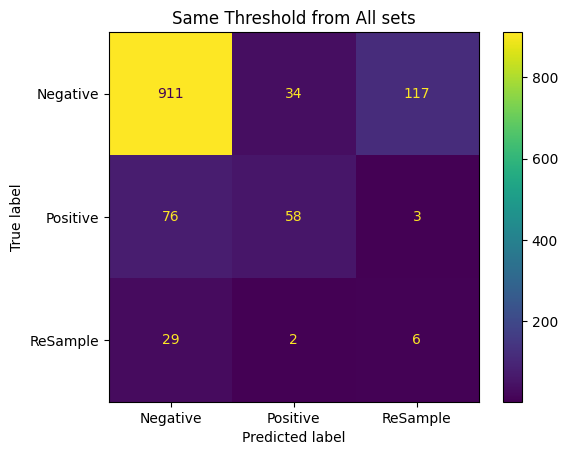

In [94]:
target_thresholds = {}
for target in fusion_train_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_train_pred
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

best_threshold = target_thresholds['N gene']
fusion_train_pred['pred'] = 1
for target in fusion_train_pred.target.unique():
    fusion_train_pred.loc[fusion_train_pred.target == target, 'pred'] = 1*(fusion_train_pred.loc[fusion_train_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_train_pred.groundtruth_label, fusion_train_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Same Threshold from All sets')


#### a.2) By target

Thresholds: {'RnaseP': 0.4864864864864865, 'MS2': 0.6063063063063063, 'S gene': 0.4522522522522523, 'E gene': 0.3441441441441442, 'ORF1ab': 0.14414414414414414, 'N gene': 0.21171171171171171}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9883673963971241
Model precision: 0.9937807021497138
Model sensitivity: 0.9932435475879465
Model F1 score: 0.9935120522640234
Model TP = 22051; TN = 2419; FP = 138; FN = 150
Model FNR = 0.05838847800700662 and FPR = 0.006219297850286178
-------------
On retest curves
-------------
Model accuracy: 0.9023016650342801
Model precision: 0.8743279569892473
Model sensitivity: 0.8598810310641111
Model F1 score: 0.8670443185604798
Model TP = 1301; TN = 2384; FP = 187; FN = 212
Model FNR = 0.08166409861325115 and FPR = 0.1256720430107527
-------------
On Retest sample level
-------------
Model accuracy: 0.7588996763754046
Model FPR: 0.408695652173913
Model FNR: 0.09206349206349207
Resam

Text(0.5, 1.0, 'Thresholding by Target from All sets')

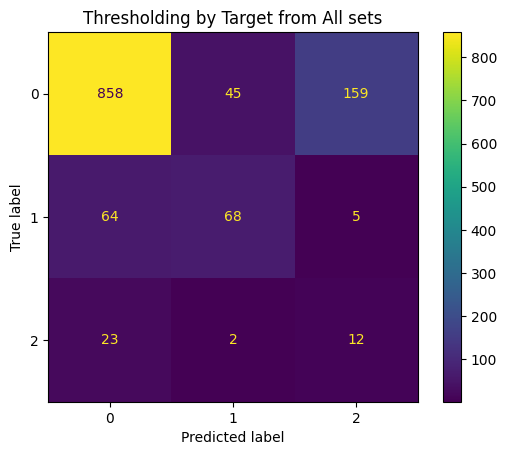

In [95]:
target_thresholds = {}
for target in fusion_train_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_train_pred[fusion_train_pred.target == target]
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_train_pred['pred'] = 1
for target in fusion_train_pred.target.unique():
    fusion_train_pred.loc[fusion_train_pred.target == target, 'pred'] = 1*(fusion_train_pred.loc[fusion_train_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_train_pred.groundtruth_label, fusion_train_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm).plot()
plt.title('Thresholding by Target from All sets')

#### b) Test Set
##### b.1) Same Threshold

Thresholds: {'RnaseP': 0.5657657657657658, 'MS2': 0.5657657657657658, 'E gene': 0.5657657657657658, 'N gene': 0.5657657657657658, 'ORF1ab': 0.5657657657657658, 'S gene': 0.5657657657657658}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9872064777327936
Model precision: 0.9938639234795164
Model sensitivity: 0.9918948126801153
Model F1 score: 0.9928783917785992
Model TP = 5507; TN = 589; FP = 34; FN = 45
Model FNR = 0.07097791798107256 and FPR = 0.006136076520483667
-------------
On retest curves
-------------
Model accuracy: 0.9135651322233105
Model precision: 0.9166666666666666
Model sensitivity: 0.8433575677461996
Model F1 score: 0.8784853700516351
Model TP = 1276; TN = 2455; FP = 116; FN = 237
Model FNR = 0.08803863298662705 and FPR = 0.08333333333333333
-------------
On Retest sample level
-------------
Model accuracy: 0.7872168284789643
Model FPR: 0.3829787234042553
Model FNR: 0.1027667984189723
Resample R

Text(0.5, 1.0, 'Same Threshold from Test set')

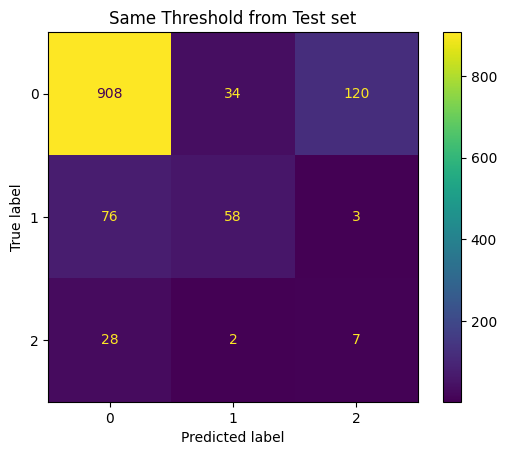

In [96]:
target_thresholds = {}
for target in fusion_vit_test_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_vit_test_pred
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_vit_test_pred['pred'] = 1
for target in fusion_vit_test_pred.target.unique():
    fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'pred'] = 1*(fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm).plot()
plt.title('Same Threshold from Test set')


#### b.2) By target

Thresholds: {'RnaseP': 0.5648648648648649, 'MS2': 0.6, 'E gene': 0.2756756756756757, 'N gene': 0.21171171171171171, 'ORF1ab': 0.1, 'S gene': 0.8018018018018018}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9880161943319838
Model precision: 0.9944043321299639
Model sensitivity: 0.9922550432276657
Model F1 score: 0.9933285250631085
Model TP = 5509; TN = 592; FP = 31; FN = 43
Model FNR = 0.06771653543307087 and FPR = 0.005595667870036101
-------------
On retest curves
-------------
Model accuracy: 0.8996082272282077
Model precision: 0.8754254594962559
Model sensitivity: 0.8499669530733642
Model F1 score: 0.8625083836351441
Model TP = 1286; TN = 2388; FP = 183; FN = 227
Model FNR = 0.08680688336520076 and FPR = 0.12457454050374404
-------------
On Retest sample level
-------------
Model accuracy: 0.7540453074433657
Model FPR: 0.43333333333333335
Model FNR: 0.09265175718849838
Resample Rate: 0.14320388349514562


Text(0.5, 1.0, 'Thresholding by Target from Test set')

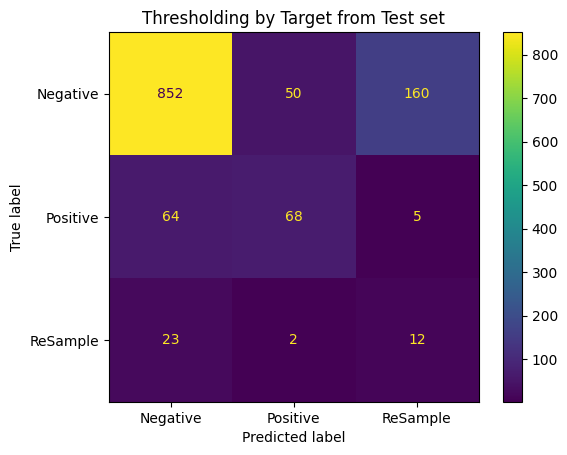

In [97]:
target_thresholds = {}
for target in fusion_vit_test_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_vit_test_pred[fusion_vit_test_pred.target == target]
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_vit_test_pred['pred'] = 1
for target in fusion_vit_test_pred.target.unique():
    fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'pred'] = 1*(fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Thresholding by Target from Test set')


### Clinical Sample

In [98]:
clinical_sample_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_clinical_pred_df.csv')
clinical_sample_pred = (clinical_sample_pred
                        .merge(join_df, on = ['curve_idx']))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


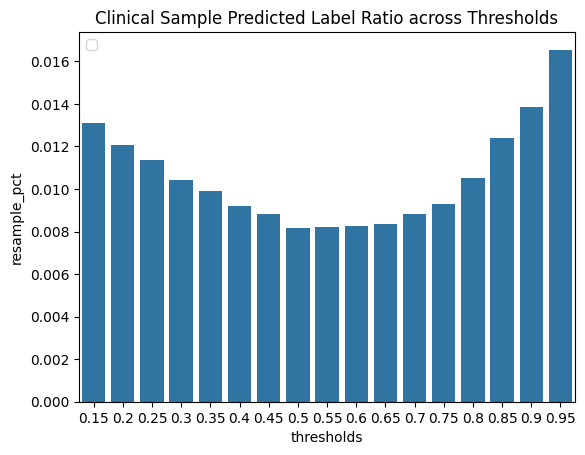

In [99]:
thresholds, pos_preds, neg_preds, resample_preds = [],[],[],[]

for i in range(15,100,5):
    clinical_sample_df = clinical_sample_pred.copy()
    clinical_sample_df['pred'] = 1*(clinical_sample_df.outputs >= i/100)

    invalid_sample_id = clinical_sample_df[(clinical_sample_df.target.isin(['MS2','RnaseP'])) & (clinical_sample_df.pred == 0)].sample_id

    clinical_sample_df = (clinical_sample_df
                        .loc[~clinical_sample_df.target.isin(['MS2','RnaseP'])]
    .groupby(['sample_id','current_sample_result','final_patient_result'])
    .agg(sample_prob = ('pred', 'mean'))
    .reset_index())
    
    n_samples = clinical_sample_df.shape[0]

    thresholds.append(i/100)
    pos_preds.append(clinical_sample_df.loc[clinical_sample_df.sample_prob >= 0.5].shape[0]/n_samples)
    neg_preds.append(clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (~clinical_sample_df.sample_id.isin(invalid_sample_id))].shape[0]/n_samples)
    resample_preds.append((clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (clinical_sample_df.sample_id.isin(invalid_sample_id))].shape[0] +
                            clinical_sample_df.loc[(clinical_sample_df.sample_prob > 0) & (clinical_sample_df.sample_prob < 0.5)].shape[0])/n_samples)


threshold_clinical_sample_df = pd.DataFrame({'thresholds': thresholds,
                                           'pos_pct': pos_preds,
                                           'neg_pct': neg_preds,
                                           'resample_pct': resample_preds})
sns.barplot(data=threshold_clinical_sample_df, x='thresholds', y='resample_pct')
# plt.axhline(y=igi_algo_retest_sample_rate, label='IGI Algo')
plt.title('Clinical Sample Predicted Label Ratio across Thresholds')
plt.legend()


Apply the same threshold from all sets on clinical samples

In [100]:
clinical_sample_pred['pred'] = 1*(clinical_sample_pred.outputs >= best_threshold)

invalid_sample_id = clinical_sample_pred[(clinical_sample_pred.target.isin(['MS2','RnaseP'])) & (clinical_sample_pred.pred == 0)].sample_id

clinical_sample_df = (clinical_sample_pred
                    .loc[~clinical_sample_pred.target.isin(['MS2','RnaseP'])]
.groupby(['sample_id','current_sample_result','final_patient_result'])
.agg(sample_prob = ('pred', 'mean'))
.reset_index())

n_samples = clinical_sample_df.shape[0]

clinical_sample_df['sample_pred'] = None
clinical_sample_df.loc[clinical_sample_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (~clinical_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (clinical_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
clinical_sample_df.loc[(clinical_sample_df.sample_prob > 0) & (clinical_sample_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
clinical_sample_df['sample_pred_3'] = clinical_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
clinical_sample_df['current_sample_result_3'] = clinical_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

print(clinical_sample_df.groupby('sample_pred_3').sample_id.count())
print(clinical_sample_df.groupby('current_sample_result_3').sample_id.count())

sample_pred_3
Negative    17523
Positive     1655
ReSample      160
Name: sample_id, dtype: int64
current_sample_result_3
Negative    16472
Positive     1628
ReSample     1238
Name: sample_id, dtype: int64


In [101]:
aggree_resample = clinical_sample_df.loc[(clinical_sample_df.sample_pred_3 == clinical_sample_df.current_sample_result_3) & (clinical_sample_df.sample_pred_3 == 'ReSample')].shape[0]
print(f'Agreed Resample {aggree_resample}')

Agreed Resample 79


### Known dilution

In [102]:
# known dilution dataset
known_df = pd.read_csv('../data/known_dilution_data.csv')
known_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_known_pred_df.csv')

known_df.loc[:,['groundtruth_target']] = 1
known_df.loc[known_df.target == 'RnaseP',['groundtruth_target']] = 0

known_pred_df = (known_df[(known_df.cycle_no == 40) & (known_df.target != 'RnaseP')]
                 .merge(known_pred[['curve_idx','outputs']], on='curve_idx'))

In [103]:
known_pred_df['encoded_amp'] = 0
known_pred_df.loc[known_pred_df.amp_status == 'Amp','encoded_amp'] = 1
known_pred_df['pred'] = 0
known_pred_df.loc[known_pred_df.outputs >= best_acc_threshold, 'pred'] = 1

Text(0.5, 1.0, 'Agreement Matrix on N gene and E gene')

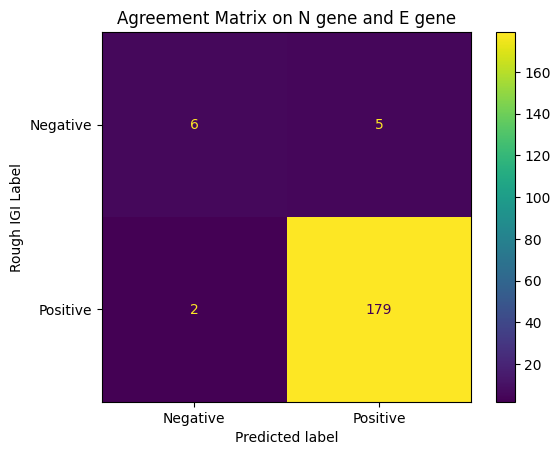

In [104]:
cm = confusion_matrix(known_pred_df[known_pred_df.target.isin(['N gene','E gene'])].encoded_amp, 
                      known_pred_df[known_pred_df.target.isin(['N gene','E gene'])].pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot()

plt.ylabel('Rough IGI Label')
plt.title('Agreement Matrix on N gene and E gene')

In [105]:
known_pred_df.loc[(known_pred_df.encoded_amp != known_pred_df.pred) & (known_pred_df.target != 'RnaseP'),
                  ['well_position','target','dilution_level','amp_status','cq','threshold','covid_variant','outputs','pred']]

,well_position,target,dilution_level,amp_status,cq,threshold,covid_variant,outputs,pred
23,A23,N gene,1,No Amp,Undetermined,14000,Omicron,0.979535,1
59,E11,N gene,10,Inconclusive,31.4131549,14000,Delta,0.999963,1
117,I23,N gene,1,Inconclusive,36.51432648,14000,Omicron,0.968563,1
140,K23,E gene,1,Amp,35.79751743,8000,Omicron,0.134656,0
141,K23,N gene,1,Inconclusive,36.6251876,14000,Omicron,0.978238,1
157,M15,N gene,1,Inconclusive,36.5084153,14000,Delta,0.982700,1
190,O23,E gene,1,Amp,34.81492146,8000,Omicron,0.221423,0


### Explore relationships between variant, dilution level and predicted probability

In [106]:
import statsmodels.api as sm

one_hot_df = 1*pd.get_dummies(known_pred_df['covid_variant'], prefix='variant')
ols_df = pd.concat([known_pred_df, one_hot_df], axis=1)
#define predictor and response variables
y = ols_df['outputs']
x = ols_df[['dilution_level','variant_Delta','variant_Omicron','variant_Wuhan']] #'target_N gene','target_E gene']]
x['dilution_level'] = np.log(x['dilution_level'])
#add constant to predictor variables
x = sm.add_constant(x)

#fit linear regression model
model = sm.OLS(y, x).fit()

#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outputs   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     9.475
Date:                Mon, 22 Jan 2024   Prob (F-statistic):           7.35e-06
Time:                        10:27:41   Log-Likelihood:                 57.969
No. Observations:                 192   AIC:                            -107.9
Df Residuals:                     188   BIC:                            -94.91
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.6588      0.027     

/tmp/ipykernel_1102017/1650251654.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['dilution_level'] = np.log(x['dilution_level'])


In [107]:
import statsmodels.formula.api as smf
x = known_pred_df[['dilution_level','covid_variant']]
x['dilution_level'] = np.log(x['dilution_level'])
y = known_pred_df[['outputs']]
ols_df = pd.concat([x,y], axis=1)

ols_model = smf.ols(formula='outputs ~ dilution_level + covid_variant', data = ols_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                outputs   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     9.475
Date:                Mon, 22 Jan 2024   Prob (F-statistic):           7.35e-06
Time:                        10:27:42   Log-Likelihood:                 57.969
No. Observations:                 192   AIC:                            -107.9
Df Residuals:                     188   BIC:                            -94.91
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/tmp/ipykernel_1102017/2588673618.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['dilution_level'] = np.log(x['dilution_level'])


In [108]:
x = known_pred_df[['dilution_level','covid_variant']]
x['dilution_level'] = (x['dilution_level'].astype(str))
y = known_pred_df[['outputs']]
ols_df = pd.concat([x,y], axis=1)

ols_model = smf.ols(formula='outputs ~ dilution_level + covid_variant', data = ols_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                outputs   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     5.760
Date:                Mon, 22 Jan 2024   Prob (F-statistic):           4.81e-06
Time:                        10:27:43   Log-Likelihood:                 63.472
No. Observations:                 192   AIC:                            -110.9
Df Residuals:                     184   BIC:                            -84.88
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/tmp/ipykernel_1102017/2772344690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['dilution_level'] = (x['dilution_level'].astype(str))


/tmp/ipykernel_1102017/345653504.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=known_pred_df, x='outputs', hue = 'dilution_level', palette='colorblind')


Text(0.5, 1.0, 'Density plot of predicted probability across dilution levels')

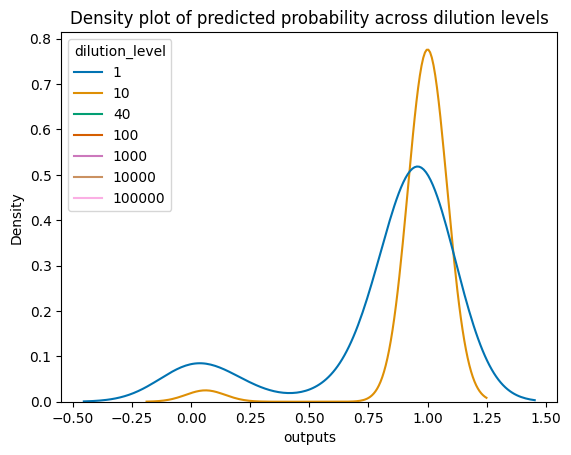

In [109]:
sns.kdeplot(data=known_pred_df, x='outputs', hue = 'dilution_level', palette='colorblind')
plt.title('Density plot of predicted probability across dilution levels')

In [110]:
np.random.seed(0)
water_well_ids = np.random.choice(fusion_vit_test_pred[fusion_vit_test_pred.sample_type == 'Negative Control (qPCR)'].sample_id.unique(), 24, replace=False)

water_output_df = fusion_vit_test_pred.loc[fusion_vit_test_pred.sample_id.isin(water_well_ids),['encoded_igi_call','outputs']]
water_output_df['dilution_level'] = 0

In [111]:
water_df = (fusion_vit_test_pred[fusion_vit_test_pred.sample_id.isin(water_well_ids)]
 .merge(join_df[['threshold','drn','cycle_no','curve_idx','test_kit']], on = 'curve_idx'))
water_df['temp'] = water_df.drn >= water_df.threshold
water_df['new_igi_call'] = 0
pass_thres_df = water_df[water_df.temp == 1].groupby('curve_idx').cycle_no.min().reset_index()
for idx in water_df.curve_idx.unique():
    
    if water_df[water_df.curve_idx == idx].test_kit.unique() == 'Thermo':
        water_df.loc[water_df.curve_idx == idx, 'new_igi_call'] = 1*(pass_thres_df[pass_thres_df.curve_idx == idx].cycle_no.mean() < 37)
    else:
        if water_df[water_df.curve_idx == idx].target.unique() == 'RnaseP':
            water_df.loc[water_df.curve_idx == idx, 'new_igi_call'] = 1*(pass_thres_df[pass_thres_df.curve_idx == idx].cycle_no.mean() < 35)
        else:
            water_df.loc[water_df.curve_idx == idx, 'new_igi_call'] = 1*(pass_thres_df[pass_thres_df.curve_idx == idx].cycle_no.mean() < 40)

print(water_df.groupby('curve_idx').new_igi_call.mean().mean())

0.075


In [112]:
boxplot_known_df = known_df.copy()
boxplot_known_df = boxplot_known_df[boxplot_known_df.target != 'RnaseP']
boxplot_known_df['temp'] = boxplot_known_df.drn >= boxplot_known_df.threshold
boxplot_known_df['new_igi_call'] = 0
known_thres_df = boxplot_known_df[boxplot_known_df.temp == 1].groupby('curve_idx').cycle_no.min().reset_index()
for idx in boxplot_known_df.curve_idx.unique():
    if boxplot_known_df[boxplot_known_df.curve_idx == idx].target.unique() == 'RnaseP':
        boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 35)
    else:
        boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 40)



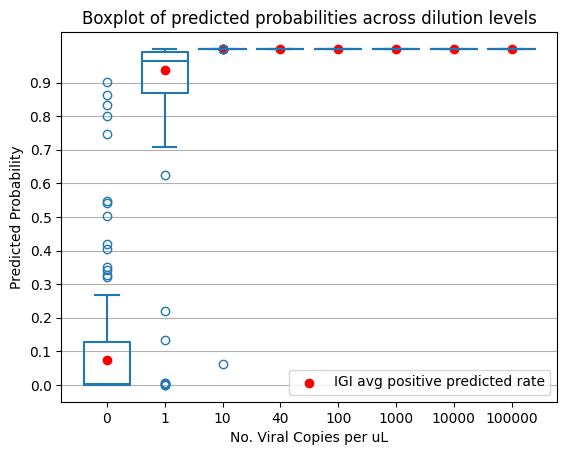

In [113]:
boxplot_df = pd.concat([known_pred_df[['dilution_level','outputs']], water_output_df[['dilution_level','outputs']]], axis=0)

sns.boxplot(data=boxplot_df, x='dilution_level', y = 'outputs', fill = False)
plt.scatter(0, water_df.groupby('curve_idx').new_igi_call.mean().mean(), color = 'red', label = 'IGI avg positive predicted rate')
plt.scatter(1, boxplot_known_df[boxplot_known_df.dilution_level == 1].new_igi_call.mean(), color = 'red')
plt.scatter(2, boxplot_known_df[boxplot_known_df.dilution_level == 10].new_igi_call.mean(), color = 'red')
plt.scatter(3, boxplot_known_df[boxplot_known_df.dilution_level == 40].new_igi_call.mean(), color = 'red')
plt.scatter(4, boxplot_known_df[boxplot_known_df.dilution_level == 100].new_igi_call.mean(), color = 'red')
plt.scatter(5, boxplot_known_df[boxplot_known_df.dilution_level == 1000].new_igi_call.mean(), color = 'red')
plt.scatter(6, boxplot_known_df[boxplot_known_df.dilution_level == 10000].new_igi_call.mean(), color = 'red')
plt.scatter(7, boxplot_known_df[boxplot_known_df.dilution_level == 100000].new_igi_call.mean(), color = 'red')

plt.title('Boxplot of predicted probabilities across dilution levels')
plt.yticks(np.arange(0,1,0.1))
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

Text(0.5, 1.0, 'Density plot of predicted probability among IGI negative predictions')

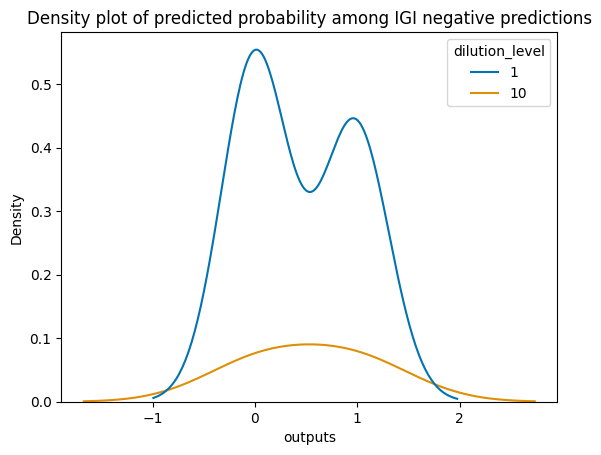

In [114]:
sns.kdeplot(data=known_pred_df[known_pred_df.amp_status != 'Amp'], x='outputs', hue = 'dilution_level', palette='colorblind')
plt.title('Density plot of predicted probability among IGI negative predictions')

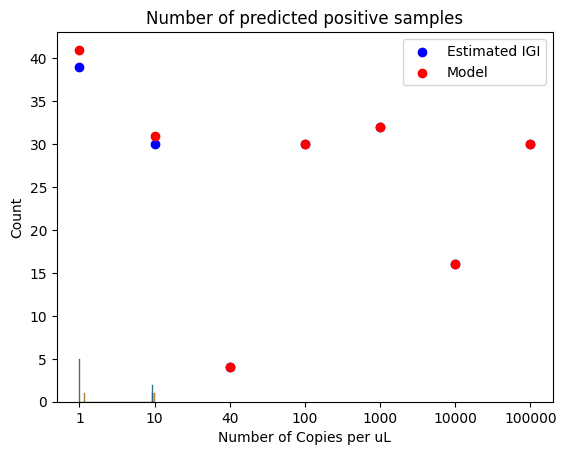

In [115]:
import matplotlib
sns.histplot(data=known_pred_df[known_pred_df.amp_status != 'Amp'], 
             x='outputs', hue = 'dilution_level', 
             binwidth=0.01,
             multiple='dodge', palette='colorblind')
plt.title('Histogram of predicted probability among IGI negative predictions')
pos_known_pred = known_pred_df.groupby('dilution_level')[['encoded_amp','pred']].sum().reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

plt.scatter(data=pos_known_pred,
             x='dilution_level', y='encoded_amp', color = 'blue')
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='pred', color = 'red')
plt.legend(labels=['Estimated IGI', 'Model'])
plt.title('Number of predicted positive samples')
plt.xlabel('Number of Copies per uL')
plt.show()

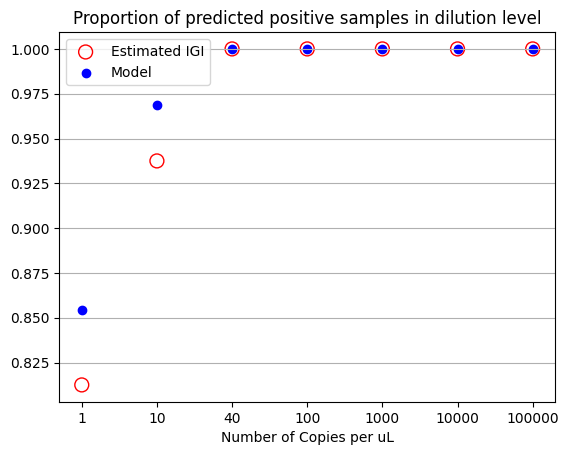

In [116]:
pos_known_pred = known_pred_df.groupby('dilution_level')[['encoded_amp','pred']].apply(lambda x: x.sum()/len(x)).reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

plt.scatter(data=pos_known_pred,
             x='dilution_level', y='encoded_amp', facecolor='none', edgecolors='red', s = 100)
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='pred', color = 'blue')
plt.legend(labels=['Estimated IGI', 'Model'])
plt.title('Proportion of predicted positive samples in dilution level')
plt.xlabel('Number of Copies per uL')
plt.grid(axis='y')
plt.show()

### Making prediction on sample level

/tmp/ipykernel_1102017/3509440832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=known_sample_df, x = 'pred', hue='dilution_level', palette='colorblind')


Text(0.5, 1.0, 'Density plot of predicted probability on sample level')

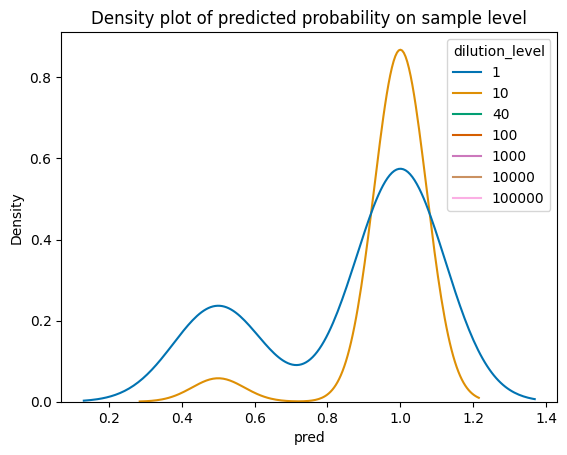

In [117]:
known_sample_df = (known_pred_df
 .groupby(['well_position','dilution_level','covid_variant'])
 .agg(pred = ('pred', 'mean'),
      igi_pred = ('encoded_amp', 'mean')))
sns.kdeplot(data=known_sample_df, x = 'pred', hue='dilution_level', palette='colorblind')
plt.title('Density plot of predicted probability on sample level')

/tmp/ipykernel_1102017/2016747490.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=known_sample_df, x = 'igi_pred', hue='dilution_level', palette='colorblind')


Text(0.5, 1.0, 'Density plot of IGI prediction on sample level')

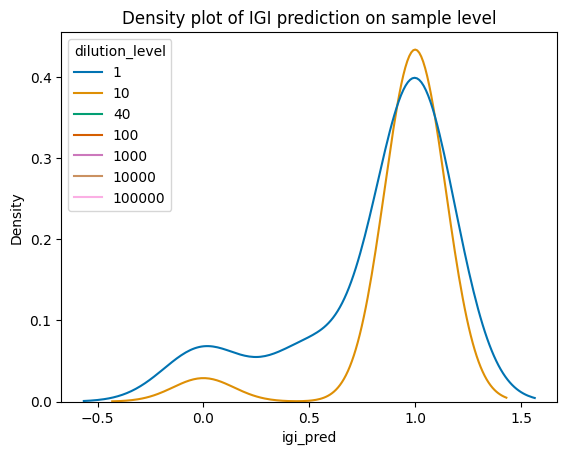

In [118]:
sns.kdeplot(data=known_sample_df, x = 'igi_pred', hue='dilution_level', palette='colorblind')
plt.title('Density plot of IGI prediction on sample level')

In [119]:

print(known_sample_df.groupby('dilution_level').agg(pos = ('pred', lambda x: sum(1*(x >= 0.5))),
                                                    neg = ('pred', lambda x: sum(1*(x < 0.5)))))

                pos  neg
dilution_level          
1                24    0
10               16    0
40                2    0
100              15    0
1000             16    0
10000             8    0
100000           15    0


In [120]:

print(known_sample_df.groupby('dilution_level').agg(pos = ('igi_pred', lambda x: sum(1*(x >= 0.5))),
                                                    neg = ('igi_pred', lambda x: sum(1*(x < 0.5)))))

                pos  neg
dilution_level          
1                21    3
10               15    1
40                2    0
100              15    0
1000             16    0
10000             8    0
100000           15    0


### Other method of combining curves

In [121]:
test_target_sample = (fusion_vit_test_pred[~fusion_vit_test_pred.target.isin(['MS2','RnaseP'])]
                      .groupby('sample_id')
                      .agg(pred = ('outputs','prod'),
                           igi_pred = ('encoded_igi_call', lambda x: 1*(np.mean(x) > 0.5)),
                           groundtruth = ('groundtruth_label', 'mean')))
test_target_sample

,pred,igi_pred,groundtruth
sample_id,,,
S087025,2.088952e-09,0,0.0
S089572,1.592114e-09,0,0.0
S089584,3.655181e-09,0,0.0
S089606,2.403677e-09,0,0.0
S089635,3.586107e-08,0,0.0
...,...,...,...
S993279,9.999988e-01,1,1.0
S993280,6.654913e-08,0,0.0
S993281,9.916373e-08,0,0.0


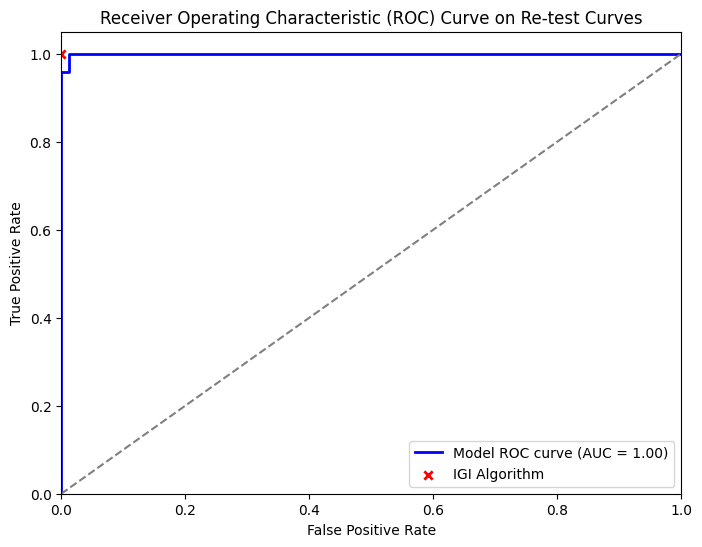

In [122]:
tn, fp, fn, tp = confusion_matrix(test_target_sample.groundtruth, test_target_sample.igi_pred).ravel()
igi_test_sample_fpr = fp/(fp + tp)
igi_test_sample_tpr = tp/(fp + tp)

test_sample_auc = roc_auc_score(test_target_sample.groundtruth, test_target_sample.pred)
test_sample_fpr, test_sample_tpr, test_sample_thresholds = roc_curve(test_target_sample.groundtruth, test_target_sample.pred)


plt.figure(figsize=(8, 6))
plt.plot(test_sample_fpr, test_sample_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_sample_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(igi_test_sample_fpr, igi_test_sample_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI Algorithm')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Curves')
plt.legend(loc='lower right')
plt.show()

In [123]:
test_target_sample = (fusion_vit_test_pred[~fusion_vit_test_pred.target.isin(['MS2','RnaseP'])]
                      .groupby('sample_id')
                      .agg(pred = ('outputs','prod'),
                           igi_pred = ('encoded_igi_call', lambda x: 1*(np.mean(x) > 0.5)),
                           groundtruth = ('groundtruth_label', 'mean')))
test_target_sample

,pred,igi_pred,groundtruth
sample_id,,,
S087025,2.088952e-09,0,0.0
S089572,1.592114e-09,0,0.0
S089584,3.655181e-09,0,0.0
S089606,2.403677e-09,0,0.0
S089635,3.586107e-08,0,0.0
...,...,...,...
S993279,9.999988e-01,1,1.0
S993280,6.654913e-08,0,0.0
S993281,9.916373e-08,0,0.0


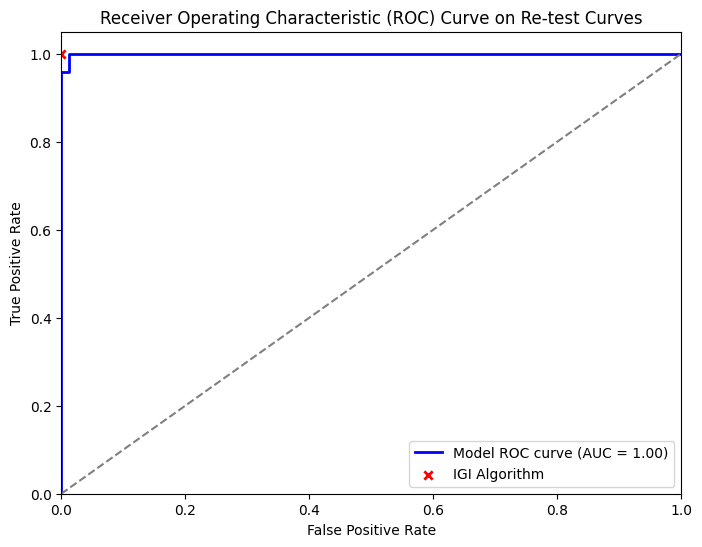

In [124]:
tn, fp, fn, tp = confusion_matrix(test_target_sample.groundtruth, test_target_sample.igi_pred).ravel()
igi_test_sample_fpr = fp/(fp + tp)
igi_test_sample_tpr = tp/(fp + tp)

test_sample_auc = roc_auc_score(test_target_sample.groundtruth, test_target_sample.pred)
test_sample_fpr, test_sample_tpr, test_sample_thresholds = roc_curve(test_target_sample.groundtruth, test_target_sample.pred)


plt.figure(figsize=(8, 6))
plt.plot(test_sample_fpr, test_sample_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_sample_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(igi_test_sample_fpr, igi_test_sample_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI Algorithm')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Curves')
plt.legend(loc='lower right')
plt.show()

<Axes: xlabel='pred', ylabel='Density'>

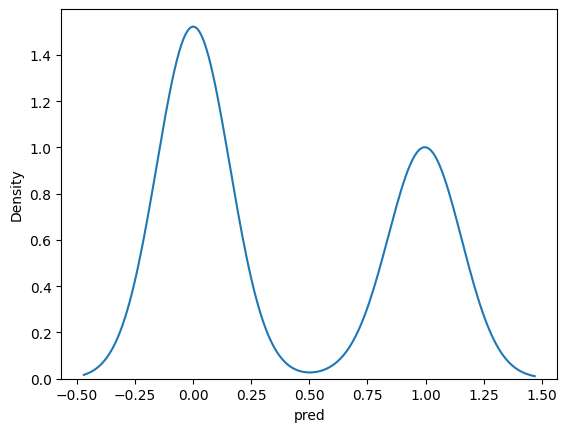

In [125]:
sns.kdeplot(data = test_target_sample, x = 'pred')

### Make predictions on all samples with groundtruth

In [41]:
df = fusion_train_pred.groupby('sample_id').curve_idx.nunique().reset_index()
groundtruth_sample_ids = df[df.curve_idx >= 3].sample_id
groundtruth_sample_df = fusion_train_pred[fusion_train_pred.sample_id.isin(groundtruth_sample_ids)]

groundtruth_sample_df['sample_label'] = None
groundtruth_sample_df.loc[groundtruth_sample_df.sample_type.isin(['Negative Control (qPCR)', 'Human Normal Negative Control (Extraction)']), 'sample_label'] = 0
groundtruth_sample_df.loc[groundtruth_sample_df.sample_type.isin(['Positive Control (qPCR)']), 'sample_label'] = 1


/tmp/ipykernel_2012215/2142547496.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  groundtruth_sample_df['sample_label'] = None


In [42]:
groundtruth_sample_df['pred'] = 1*(groundtruth_sample_df.outputs >= best_acc_thres)

invalid_sample_id = groundtruth_sample_df[(groundtruth_sample_df.target.isin(['MS2','RnaseP'])) & (groundtruth_sample_df.pred == 0)].sample_id

groundtruth_viral_df = (groundtruth_sample_df
                    .loc[~groundtruth_sample_df.target.isin(['MS2','RnaseP'])]
.groupby(['sample_id','sample_type','sample_label'])
.agg(sample_prob = ('pred', 'mean'),
     igi_sample_prob = ('encoded_igi_call','mean'))
.reset_index())

groundtruth_viral_df['sample_pred'] = None
groundtruth_viral_df.loc[groundtruth_viral_df.sample_prob >= 0.5, 'sample_pred'] = 'Positive'
groundtruth_viral_df.loc[(groundtruth_viral_df.sample_prob == 0) & (~groundtruth_viral_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
groundtruth_viral_df.loc[(groundtruth_viral_df.sample_prob == 0) & (groundtruth_viral_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
groundtruth_viral_df.loc[(groundtruth_viral_df.sample_prob > 0) & (groundtruth_viral_df.sample_prob < 0.5), 'sample_pred'] = 'Inconclusive'
groundtruth_viral_df['sample_pred_3'] = groundtruth_viral_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

invalid_sample_id = groundtruth_sample_df[(groundtruth_sample_df.target.isin(['MS2','RnaseP'])) & (groundtruth_sample_df.encoded_igi_call == 0)].sample_id
groundtruth_viral_df['igi_sample_pred'] = None
groundtruth_viral_df.loc[groundtruth_viral_df.igi_sample_prob >= 0.5, 'igi_sample_pred'] = 'Positive'
groundtruth_viral_df.loc[(groundtruth_viral_df.igi_sample_prob == 0) & (~groundtruth_viral_df.sample_id.isin(invalid_sample_id)), 'igi_sample_pred'] = 'Negative'
groundtruth_viral_df.loc[(groundtruth_viral_df.igi_sample_prob == 0) & (groundtruth_viral_df.sample_id.isin(invalid_sample_id)), 'igi_sample_pred'] = 'Invalid'
groundtruth_viral_df.loc[(groundtruth_viral_df.igi_sample_prob > 0) & (groundtruth_viral_df.igi_sample_prob < 0.5), 'igi_sample_pred'] = 'Inconclusive'
groundtruth_viral_df['igi_sample_pred_3'] = groundtruth_viral_df.igi_sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})



/tmp/ipykernel_2012215/1719869205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  groundtruth_sample_df['pred'] = 1*(groundtruth_sample_df.outputs >= best_acc_thres)


In [43]:
groundtruth_viral_df.groupby(['sample_label','sample_pred_3']).sample_id.count()

sample_label  sample_pred_3
0             Negative         299
              Positive           4
              ReSample         408
1             Positive         464
              ReSample           5
Name: sample_id, dtype: int64

In [44]:
groundtruth_viral_df.groupby(['sample_label','igi_sample_pred_3']).sample_id.count()

sample_label  igi_sample_pred_3
0             Negative             230
              Positive               4
              ReSample             477
1             Positive             469
Name: sample_id, dtype: int64

In [47]:
groundtruth_sample_df[(groundtruth_sample_df.groundtruth_label != groundtruth_sample_df.encoded_igi_call) & (groundtruth_sample_df.encoded_igi_call == 0)]

,curve_idx,outputs,igi_fp,igi_fn,groundtruth_label,encoded_igi_call,target,sample_id,final_patient_result,current_sample_result,sample_type,record_type,retest_sample_id_1,sample_label,pred
608,2218,0.653765,4.116353e-04,0.555581,1,0,MS2,S136862,NaN,Invalid,Human Normal Negative Control (Extraction),Control Sample,,0,1
2079,65881,0.948017,1.089538e-08,0.950351,1,0,RnaseP,S699724,NaN,NaN,Human Normal Negative Control (Extraction),Control Sample,,0,1
5304,45903,0.957405,1.238430e-07,0.901128,1,0,MS2,S143158,ReSample,Invalid,Human Normal Negative Control (Extraction),Control Sample,,0,1
8018,65983,0.615641,3.455600e-05,0.627905,1,0,RnaseP,S699734,NaN,NaN,Human Normal Negative Control (Extraction),Control Sample,,0,1
12352,52540,0.003892,1.995555e-06,0.002061,1,0,E gene,S680676,NaN,NaN,Positive Control (qPCR),Control Sample,,1,0
13894,42614,0.999797,6.311817e-09,0.033978,1,0,MS2,S137846,NaN,Invalid,Human Normal Negative Control (Extraction),Control Sample,,0,1
15608,103252,0.016232,5.191740e-05,0.004542,1,0,E gene,S1092318,NaN,NaN,Positive Control (qPCR),Control Sample,,1,0
16896,65767,0.977192,1.099340e-10,0.977982,1,0,RnaseP,S699765,NaN,NaN,Human Normal Negative Control (Extraction),Control Sample,,0,1
20280,52562,0.001941,4.562818e-07,0.001042,1,0,E gene,S680677,NaN,NaN,Positive Control (qPCR),Control Sample,,1,0
22215,45925,0.836124,8.218530e-07,0.782043,1,0,MS2,S143161,ReSample,Invalid,Human Normal Negative Control (Extraction),Control Sample,,0,1


In [50]:
groundtruth_sample_df[groundtruth_sample_df.sample_id == 'S1092318']

,curve_idx,outputs,igi_fp,igi_fn,groundtruth_label,encoded_igi_call,target,sample_id,final_patient_result,current_sample_result,sample_type,record_type,retest_sample_id_1,sample_label,pred
13953,103636,0.963090,0.000330,0.000068,1,1,N gene,S1092318,NaN,NaN,Positive Control (qPCR),Control Sample,,1,1
15205,104020,0.122905,0.000175,0.127450,0,0,RnaseP,S1092318,NaN,NaN,Positive Control (qPCR),Control Sample,,1,0
15608,103252,0.016232,0.000052,0.004542,1,0,E gene,S1092318,NaN,NaN,Positive Control (qPCR),Control Sample,,1,0


In [171]:
df = groundtruth_sample_df.copy()
df = (df.merge(join_df[['curve_idx','cycle_no','drn','threshold','test_kit']], on = 'curve_idx'))

df['temp'] = 1*(df.drn > df.threshold)
min_cycle_df = df[df.temp == 1].groupby(['sample_id','curve_idx','target','test_kit','sample_label','sample_type']).cycle_no.min().reset_index()
    
min_cycle_df['new_igi_call'] = 0

for id in min_cycle_df.sample_id.unique():
    if min_cycle_df[min_cycle_df.sample_id == id].test_kit.unique() == 'Thermo':
        min_cycle_df.loc[min_cycle_df.sample_id == id,'new_igi_call'] = 1*(min_cycle_df.cycle_no < 37)
    else:
        for target in min_cycle_df[min_cycle_df.sample_id == id].target.unique():
            if target == 'RnaseP':
                min_cycle_df.loc[(min_cycle_df.sample_id == id) & (min_cycle_df.target == target),'new_igi_call'] = 1*(min_cycle_df.cycle_no < 35)
            else:
                min_cycle_df.loc[(min_cycle_df.sample_id == id) & (min_cycle_df.target == target),'new_igi_call'] = 1*(min_cycle_df.cycle_no < 40)

invalid_sample_id = min_cycle_df[(min_cycle_df.target.isin(['MS2','RnaseP'])) & (min_cycle_df.new_igi_call == 0)].sample_id
estimated_igi_viral_df = (min_cycle_df
                    .loc[~min_cycle_df.target.isin(['MS2','RnaseP'])]
.groupby(['sample_id','sample_type','sample_label'])
.agg(estimated_igi_prob = ('new_igi_call', 'mean'))
.reset_index())

estimated_igi_viral_df['estimated_igi_pred'] = None
estimated_igi_viral_df.loc[estimated_igi_viral_df.estimated_igi_prob >= 0.5, 'estimated_igi_pred'] = 'Positive'
estimated_igi_viral_df.loc[(estimated_igi_viral_df.estimated_igi_prob == 0) & (~estimated_igi_viral_df.sample_id.isin(invalid_sample_id)), 'estimated_igi_pred'] = 'Negative'
estimated_igi_viral_df.loc[(estimated_igi_viral_df.estimated_igi_prob == 0) & (estimated_igi_viral_df.sample_id.isin(invalid_sample_id)), 'estimated_igi_pred'] = 'Invalid'
estimated_igi_viral_df.loc[(estimated_igi_viral_df.estimated_igi_prob > 0) & (estimated_igi_viral_df.estimated_igi_prob < 0.5), 'estimated_igi_pred'] = 'Inconclusive'
estimated_igi_viral_df['estimated_igi_pred_3'] = estimated_igi_viral_df.estimated_igi_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})


In [172]:
estimated_igi_viral_df.groupby(['sample_label','estimated_igi_pred_3']).sample_id.count()

sample_label  estimated_igi_pred_3
0             Negative                 33
              Positive                 63
1             Positive                465
Name: sample_id, dtype: int64

<Axes: >

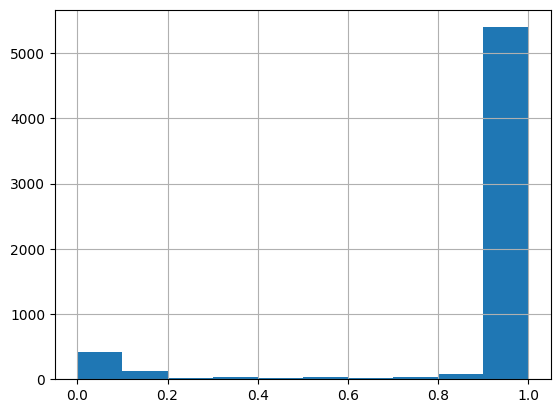

In [58]:
fusion_test_pred.outputs.hist()